In [780]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from itertools import combinations

import networkx as nx

import random

from ineqpy import inequality

import ast

import json

from adjustText import adjust_text

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.gridspec as gridspec

import scipy.stats as stats

In [3]:
df = pd.read_csv('/Users/trevor/Desktop/Research/climate-trends/climate_articles_unique_english.csv')

/var/folders/1g/6pgh6bw14hgcbgppl7q0jgfr0000gn/T/ipykernel_709/1539378662.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/trevor/Desktop/Research/climate-trends/climate_articles_unique_english.csv')


In [4]:
df.shape

(328015, 50)

In [5]:
df.dropna(subset = 'author', inplace = True)

In [6]:
df.shape

(289698, 50)

In [7]:
df['author_dict'] = df['author'].apply(str).apply(ast.literal_eval) 

In [20]:
rando_dict = {"affiliation" : []}

In [24]:
not rando_dict.get("affiliation")

True

In [19]:
df['author_dict'][1]

[{'given': 'Paul',
  'family': 'Smaglik',
  'sequence': 'first',
  'affiliation': []}]

In [25]:
def check_affiliation_present(list_of_dicts):
    """
    Input: a list of dicts which contain author information
    Output: a boolean of whether there is any affiliation information in these dicts
    """
    for dictionary in list_of_dicts:
        if dictionary.get('affiliation'):
            return True
    return False

In [26]:
df['author_affiliation_bool'] = df['author_dict'].apply(lambda x: check_affiliation_present(x))

In [27]:
df['author_affiliation_bool'].value_counts()

author_affiliation_bool
False    207363
True      82335
Name: count, dtype: int64

In [31]:
affiliated_df = df[df['author_affiliation_bool'] == True].reset_index()

In [34]:
affiliated_df['author_dict'][4]

[{'given': 'Francis W.',
  'family': 'Zwiers',
  'sequence': 'first',
  'affiliation': [{'name': 'F. W. Zwiers is at the Canadian Centre for Climate Modelling and Analysis, Victoria, BC.'}]},
 {'given': 'Andrew J.',
  'family': 'Weaver',
  'sequence': 'additional',
  'affiliation': [{'name': 'A. J. Weaver is at the School of Earth and Ocean Sciences, University of Victoria, Victoria, BC, Canada.'}]}]

In [35]:
affiliated_df['author_dict'][4][0].get('affiliation')[0].get('name', '')

'F. W. Zwiers is at the Canadian Centre for Climate Modelling and Analysis, Victoria, BC.'

In [387]:
countries = [
    "Afghanistan",
    "Albania",
    "Algeria",
    "Andorra",
    "Angola",
    "Antigua and Barbuda",
    "Argentina",
    "Armenia",
    "Australia",
    "Austria",
    "Azerbaijan",
    "Bahamas",
    "Bahrain",
    "Bangladesh",
    "Barbados",
    "Belarus",
    "Belgium",
    "Belize",
    "Benin",
    "Bhutan",
    "Bolivia",
    "Bosnia and Herzegovina",
    "Botswana",
    "Brazil",
    "Brunei",
    "Bulgaria",
    "Burkina Faso",
    "Burundi",
    "Cape Verde",
    "Cambodia",
    "Cameroon",
    "Canada",
    "Central African Republic",
    "Chad",
    "Chile",
    "China",
    "Colombia",
    "Comoros",
    "Democratic Republic of the Congo",
    "Costa Rica",
    "Côte d'Ivoire",
    "Croatia",
    "Cuba",
    "Cyprus",
    "Czech Republic",  # or "Czechia"
    "Denmark",
    "Djibouti",
    "Dominica",
    "Dominican Republic",
    "Ecuador",
    "Egypt",
    "El Salvador",
    "Equatorial Guinea",
    "Eritrea",
    "Estonia",
    "Eswatini",
    "Ethiopia",
    "Fiji",
    "Finland",
    "France",
    "Gabon",
    "Gambia",
    "Georgia",
    "Germany",
    "Ghana",
    "Greece",
    "Grenada",
    "Guatemala",
    "Guinea",
    "Guinea-Bissau",
    "Guyana",
    "Haiti",
    "Honduras",
    "Hungary",
    "Iceland",
    "India",
    "Indonesia",
    "Iran",
    "Iraq",
    "Ireland",
    "Israel",
    "Italy",
    "Jamaica",
    "Japan",
    "Jordan",
    "Kazakhstan",
    "Kenya",
    "Kiribati",
    "Kuwait",
    "Kyrgyzstan",
    "Laos",
    "Latvia",
    "Lebanon",
    "Lesotho",
    "Liberia",
    "Libya",
    "Liechtenstein",
    "Lithuania",
    "Luxembourg",
    "Madagascar",
    "Malawi",
    "Malaysia",
    "Maldives",
    "Mali",
    "Malta",
    "Marshall Islands",
    "Mauritania",
    "Mauritius",
    "Mexico",
    "Micronesia",
    "Moldova",
    "Monaco",
    "Mongolia",
    "Montenegro",
    "Morocco",
    "Mozambique",
    "Myanmar",
    "Namibia",
    "Nauru",
    "Nepal",
    "Netherlands",
    "New Zealand",
    "Nicaragua",
    "Niger",
    "Nigeria",
    "North Korea",
    "North Macedonia",
    "Norway",
    "Oman",
    "Pakistan",
    "Palau",
    "Palestine",
    "Panama",
    "Papua New Guinea",
    "Paraguay",
    "Peru",
    "Philippines",
    "Poland",
    "Portugal",
    "Qatar",
    "Republic of the Congo",
    "Romania",
    "Russia",
    "Rwanda",
    "Saint Kitts and Nevis",
    "Saint Lucia",
    "Saint Vincent and the Grenadines",
    "Samoa",
    "San Marino",
    "Sao Tome and Principe",
    "Saudi Arabia",
    "Senegal",
    "Serbia",
    "Seychelles",
    "Sierra Leone",
    "Singapore",
    "Slovakia",
    "Slovenia",
    "Solomon Islands",
    "Somalia",
    "South Africa",
    "South Korea",
    "South Sudan",
    "Spain",
    "Sri Lanka",
    "Sudan",
    "Suriname",
    "Sweden",
    "Switzerland",
    "Syria",
    "Taiwan",
    "Tajikistan",
    "Tanzania",
    "Thailand",
    "Timor-Leste",
    "Togo",
    "Tonga",
    "Trinidad and Tobago",
    "Tunisia",
    "Türkiye",
    "Turkmenistan",
    "Tuvalu",
    "Uganda",
    "Ukraine",
    "United Arab Emirates",
    "UK",
    "USA",
    "Uruguay",
    "Uzbekistan",
    "Vanuatu",
    "Vatican City",
    "Venezuela",
    "Vietnam",
    "Yemen",
    "Zambia",
    "Zimbabwe",
    "Kosovo" 
]

In [134]:
len(countries)
# 197 countries

197

In [388]:
states = [
    {"code": "US", "name": "USA"},
    {"code": "USA", "name": "USA"},
    {"code": "AL", "name": "Alabama"},
    {"code": "AK", "name": "Alaska"},
    {"code": "AZ", "name": "Arizona"},
    {"code": "AR", "name": "Arkansas"},
    {"code": "CA", "name": "California"},
    {"code": "CO", "name": "Colorado"},
    {"code": "CT", "name": "Connecticut"},
    {"code": "DE", "name": "Delaware"},
    {"code": "FL", "name": "Florida"},
    {"code": "GA", "name": "Georgia"},
    {"code": "HI", "name": "Hawaii"},
    {"code": "ID", "name": "Idaho"},
    {"code": "IL", "name": "Illinois"},
    {"code": "IN", "name": "Indiana"},
    {"code": "IA", "name": "Iowa"},
    {"code": "KS", "name": "Kansas"},
    {"code": "KY", "name": "Kentucky"},
    {"code": "LA", "name": "Louisiana"},
    {"code": "ME", "name": "Maine"},
    {"code": "MD", "name": "Maryland"},
    {"code": "MA", "name": "Massachusetts"},
    {"code": "MI", "name": "Michigan"},
    {"code": "MN", "name": "Minnesota"},
    {"code": "MS", "name": "Mississippi"},
    {"code": "MO", "name": "Missouri"},
    {"code": "MT", "name": "Montana"},
    {"code": "NE", "name": "Nebraska"},
    {"code": "NV", "name": "Nevada"},
    {"code": "NH", "name": "New Hampshire"},
    {"code": "NJ", "name": "New Jersey"},
    {"code": "NM", "name": "New Mexico"},
    {"code": "NY", "name": "New York"},
    {"code": "NC", "name": "North Carolina"},
    {"code": "ND", "name": "North Dakota"},
    {"code": "OH", "name": "Ohio"},
    {"code": "OK", "name": "Oklahoma"},
    {"code": "OR", "name": "Oregon"},
    {"code": "PA", "name": "Pennsylvania"},
    {"code": "RI", "name": "Rhode Island"},
    {"code": "SC", "name": "South Carolina"},
    {"code": "SD", "name": "South Dakota"},
    {"code": "TN", "name": "Tennessee"},
    {"code": "TX", "name": "Texas"},
    {"code": "UT", "name": "Utah"},
    {"code": "VT", "name": "Vermont"},
    {"code": "VA", "name": "Virginia"},
    {"code": "WA", "name": "Washington"},
    {"code": "WV", "name": "West Virginia"},
    {"code": "WI", "name": "Wisconsin"},
    {"code": "WY", "name": "Wyoming"},
    {"code": "PR", "name": "Puerto Rico"}
]

In [390]:
state_codes = [entry.get('code') for entry in states]

In [391]:
country_codes  = {
    # A
    "AF": "Afghanistan",
    "AX": "Åland Islands",
    "AL": "Albania",
    "DZ": "Algeria",
    "AS": "USA",  # American Samoa (US territory)
    "AD": "Andorra",
    "AO": "Angola",
    #"AI": "Anguilla", # confused with artificial intelligence
    "AQ": "Antarctica",
    "AG": "Antigua and Barbuda",
    "AR": "Argentina",
    "AM": "Armenia",
    "AW": "Aruba",
    "AU": "Australia",
    "AT": "Austria",
    "AZ": "Azerbaijan",

    # B
    "BS": "Bahamas",
    "BH": "Bahrain",
    "BD": "Bangladesh",
    "BB": "Barbados",
    "BY": "Belarus",
    "BE": "Belgium",
    "BZ": "Belize",
    "BJ": "Benin",
    "BM": "Bermuda",
    "BT": "Bhutan",
    "BO": "Bolivia",
    "BQ": "Netherlands", # Bonaire, Sint Eustatius and Saba part of Carribean Netherlands
    "BA": "Bosnia and Herzegovina",
    "BW": "Botswana",
    "BV": "Bouvet Island",
    "BR": "Brazil",
    "IO": "UK",  # British Indian Ocean Territory
    "BN": "Brunei Darussalam",
    "BG": "Bulgaria",
    "BF": "Burkina Faso",
    "BI": "Burundi",

    # C
    "KH": "Cambodia",
    "CM": "Cameroon",
    "CA": "Canada",
    "CV": "Cape Verde",
    "KY": "UK",  # Cayman Islands
    "CF": "Central African Republic",
    "TD": "Chad",
    "CL": "Chile",
    "CN": "China",
    "CX": "Australia", # Christmas Island Austrialian Territory
    "CC": "Australia",  # Cocos (Keeling) Islands (Australian territory)
    "CO": "Colombia",
    "KM": "Comoros",
    "CD": "Democratic Republic of the Congo",  # Democratic Republic of the Congo
    "CG": "Republic of the Congo",  # Republic of the Congo
    "CK": "Cook Islands",
    "CR": "Costa Rica",
    "CI": "Côte d'Ivoire",
    "HR": "Croatia",
    "CU": "Cuba",
    "CW": "Curaçao",
    "CY": "Cyprus",
    "CZ": "Czech Republic",

    # D
    "DK": "Denmark",
    "DJ": "Djibouti",
    "DM": "Dominica",
    "DO": "Dominican Republic",

    # E
    "EC": "Ecuador",
    "EG": "Egypt",
    "SV": "El Salvador",
    "GQ": "Equatorial Guinea",
    "ER": "Eritrea",
    "EE": "Estonia",
    "SZ": "Eswatini",
    "ET": "Ethiopia",

    # F
    "FK": "UK",
    "FO": "Denmark",
    "FJ": "Fiji",
    "FI": "Finland",
    "FR": "France",
    "GF": "France", # French Guiana is an overseas department of France
    "PF": "France", # French Polynesia an overseas collectivity of France
    "TF": "France",  # French Southern Territories (overseas territory)

    # G
    "GA": "Gabon",
    "GM": "Gambia",
    "GE": "Georgia",
    "DE": "Germany",
    "GH": "Ghana",
    "GI": "Gibraltar",
    "GR": "Greece",
    "GL": "Greenland",
    "GD": "Grenada",
    "GP": "Guadeloupe",
    "GU": "Guam",
    "GT": "Guatemala",
    "GG": "Guernsey",
    "GN": "Guinea",
    "GW": "Guinea-Bissau",
    "GY": "Guyana",

    # H
    "HT": "Haiti",
    "HM": "Australia", # Heard Island and McDonald Islands Australian territory
    "VA": "Vatican City", 
    "HN": "Honduras",
    "HK": "Hong Kong",
    "HU": "Hungary",

    # I
    "IS": "Iceland",
    "IN": "India",
    "ID": "Indonesia",
    "IR": "Iran",
    "IQ": "Iraq",
    "IE": "Ireland",
    "IM": "Isle of Man",
    "IL": "Israel",
    "IT": "Italy",

    # J
    "JM": "Jamaica",
    "JP": "Japan",
    "JE": "Jersey",
    "JO": "Jordan",

    # K
    "KZ": "Kazakhstan",
    "KE": "Kenya",
    "KI": "Kiribati",
    "KP": "North Korea",
    "KR": "South Korea",  # changed from just "Korea"
    "KW": "Kuwait",
    "KG": "Kyrgyzstan",

    # L
    "LA": "Laos",
    "LV": "Latvia",
    "LB": "Lebanon",
    "LS": "Lesotho",
    "LR": "Liberia",
    "LY": "Libya",
    "LI": "Liechtenstein",
    "LT": "Lithuania",
    "LU": "Luxembourg",

    # M
    "MO": "Macao",
    "MG": "Madagascar",
    "MW": "Malawi",
    "MY": "Malaysia",
    "MV": "Maldives",
    "ML": "Mali",
    "MT": "Malta",
    "MH": "Marshall Islands",
    "MQ": "Martinique",
    "MR": "Mauritania",
    "MU": "Mauritius",
    "YT": "Mayotte",
    "MX": "Mexico",
    "FM": "Micronesia",
    "MD": "Moldova",
    "MC": "Monaco",
    "MN": "Mongolia",
    "ME": "Montenegro",
    "MS": "Montserrat",
    "MA": "Morocco",
    "MZ": "Mozambique",
    "MM": "Myanmar",

    # N
    "NA": "Namibia",
    "NR": "Nauru",
    "NP": "Nepal",
    "NL": "Netherlands",
    "NC": "France", # NC  territory of France
    "NZ": "New Zealand",
    "NI": "Nicaragua",
    "NE": "Niger",
    "NG": "Nigeria",
    "NU": "Niue",
    "NF": "Norfolk Island",
    "MK": "North Macedonia",
    "MP": "USA",  # Northern Mariana Islands (US territory)
    "NO": "Norway",

    # O
    "OM": "Oman",

    # P
    "PK": "Pakistan",
    "PW": "Palau",
    "PS": "Palestine",
    "PA": "Panama",
    "PG": "Papua New Guinea",
    "PY": "Paraguay",
    "PE": "Peru",
    "PH": "Philippines",
    "PN": "UK",  # Pitcairn Islands
    "PL": "Poland",
    "PT": "Portugal",
    "PR": "Puerto Rico",
    
    # Q
    "QA": "Qatar",

    # R
    "RE": "Réunion",
    "RO": "Romania",
    "RU": "Russia",
    "RW": "Rwanda",

    # S
    "BL": "Saint Barthélemy",
    "SH": "UK",  # Saint Helena, Ascension and Tristan da Cunha
    "KN": "Saint Kitts and Nevis",
    "LC": "Saint Lucia",
    "MF": "France",  # Saint Martin (French part)
    "PM": "Saint Pierre and Miquelon",
    "VC": "Saint Vincent and the Grenadines",
    "WS": "Samoa", 
    "SM": "San Marino",
    "ST": "Sao Tome and Principe",
    "SA": "Saudi Arabia",
    "SN": "Senegal",
    "RS": "Serbia",
    "SC": "Seychelles",
    "SL": "Sierra Leone",
    "SG": "Singapore",
    "SX": "Netherlands",  # Sint Maarten (Dutch part)
    "SK": "Slovakia",
    "SI": "Slovenia",
    "SB": "Solomon Islands",
    "SO": "Somalia",
    "ZA": "South Africa",
    "GS": "South Georgia and the South Sandwich Islands",
    "SS": "South Sudan",
    "ES": "Spain",
    "LK": "Sri Lanka",
    "SD": "Sudan",
    "SR": "Suriname",
    "SJ": "Norway",  # Svalbard and Jan Mayen
    "SE": "Sweden",
    "CH": "Switzerland",
    "SY": "Syrian Arab Republic",

    # T
    "TW": "Taiwan",
    "TJ": "Tajikistan",
    "TZ": "Tanzania",
    "TH": "Thailand",
    "TL": "Timor-Leste",
    "TG": "Togo",
    "TK": "Tokelau",
    "TO": "Tonga",
    "TT": "Trinidad and Tobago",
    "TN": "Tunisia",
    "TR": "Türkiye",
    "TM": "Turkmenistan",
    "TC": "UK",  # Turks and Caicos Islands
    "TV": "Tuvalu",

    # U
    "UG": "Uganda",
    "UA": "Ukraine",
    "AE": "United Arab Emirates",
    "GB": "UK",  # United Kingdom
    "UM": "USA",  # US Minor Outlying Islands
    "US": "USA",
    "UY": "Uruguay",
    "UZ": "Uzbekistan",

    # V
    "VU": "Vanuatu",
    "VE": "Venezuela",
    "VN": "Vietnam",
    "VG": "UK",  # British Virgin Islands
    "VI": "USA", # US Virgin Islands

    # W
    "WF": "Wallis and Futuna",
    "EH": "Western Sahara",

    # Y
    "YE": "Yemen",

    # Z
    "ZM": "Zambia",
    "ZW": "Zimbabwe",
}

In [409]:
global_cities = {
    "belgrade" : "Serbia",
    "berkeley" : "USA",
    "seattle" : "USA",
    "davis" : "USA",
    "nsw" : "Australia",
    "novi sad" : "Serbia",
    "paris" : "France",
    "exeter" : "UK",
    "boston" :"USA",
    "santa barbara" : "USA",
    "london" : "UK",
    "bnin" : "Poland",
    "espaa" : "Spain",
    "oxford" : "UK",
    "columbia" : "USA",
    "sydney" : "Australia",
    "seoul" : "South Korea",
    "hiroshima" : "Japan",
    "shinshu" : "Japan",
    "yokohama"  :"Japan",
    "beijing" : "China",
    "new delhi" :"India",
    "nihon" : "Japan",
    "madison" : "USA",
    "lao pdr" :"Laos",
    "sngl" :"Sengal",
    "ahmedabad" : "India",
    "beograd" : "Serbia",
    "algrie": "Algeria",
    "university cambridge": "UK",
    "los angeles": "US",
    "libya": "Libya",
    "tottori university": "Japan",
    "ivory coast": "Côte d'Ivoire",
    "san francisco": "US",
    "afghanistan": "Afghanistan",
    "west indies": "West Indies",
    "kobe university": "Japan",
    "boulder": "USA",
    "gambia": "Gambia",
    "bern": "Switzerland",
    "kanazawa": "Japan",
    "tajikistan": "tajikistan",
    "chiba": "Japan",
    "faroe islands": "Denmark",
    "dominica": "Dominican Republic",
    "paraguay": "Paraguay",
    "cabon": "Gabon",
    "CN": "China",
    "london": "UK",
    "berlin": "Germany",
    "copenhagen": "Denmark",
    "rikkyo": "Japan",
    "iwate": "Japan",
    "andorra": "Andorra",
    "tonga": "Tonga",
    "hokkaido": "Japan",
    "nicaragua": "Nicaragua",
    "qld": "Australia",
    "ontario": "Canada",
    "el salvador": "El Salvador",
    "chad": "Chad",
    "uppsala": "Sweden",
    "seikei": "Japan",
    "temple": "USA",
    "ann arbor": "USA",
    "cornell": "USA",
    "columbia": "USA",
    "queensland": "Australia",
    "ni": "UK",
    "chinese academy": "China",
    "new caledonia": "France",
    "monaco": "Monaco",
    "honduras": "Honduras",
    "keio": "Japan",
    "nagasaki": "Japan",
    "CH": "Switzerland",
    "philadelphia": "USA",
    "kangwon": "South Korea",
    "miyazaki": "Japan",
    "italia": "Italy",
    "melbourne": "Australia",
    "las vegas": "USA",
    "adelaide": "Australia",
    "queensland": "Australia",
    "guadeloupe": "France",
    "islamabad": "Pakistan",
    "ibaraki": "Japan",
    "ain shams": "Egypt",
    "kolkata": "India",
    "british columbia": "Canada",
    "micronesia": "Micronesia",
    "taipei": "Taiwan",
    "tamil nadu": "India",
    "osaka university": "Japan",
    "suriname": "Suriname",
    "bahamas": "Bahamas",
    "it": "Italy",
    "gk a": "guernsey",
    "burundi": "Burundi",
    "slovenija": "Slovenia",
    "nber": "USA",
    "witwatersrand": "South Africa",
    "san diego": "USA",
    "college park": "USA",
    "toronto": "Canada",
    "udaipur": "India",
    "dortmund": "Germany",
    "santa cruz": "USA",
    "shizuoka": "Japan",
    "wageningen": "Netherlands",
    "princeton": "USA",
    "york university": "Canada",
    "akita": "Japan",
    "istanbul": "Türkiye", 
    "victoria": "Australia", 
    "nz": "New Zealand",
    "guyana": "Guyana",
    "kanagawa": "Japan",
    "tokyo": "Japan",
    "reno": "USA",
    "ng w": "Nigeria",
    "ehime university": "Japan",
    "rutgers": "USA",
    "jp": "Japan", 
    "victoria university wellington": "New Zealand",
    "university punjab": "Pakistan",
    "harvard": "USA",
    "exeter": "UK",
    "fort collins": "USA",
    "laramie": "USA",
    "university park": "USA",
    "panam": "Panama",
    "cl": "Chile",
    "manchester": "UK",
    "london": "UK",
    "san marino": "San Marino",
    "oxford": "UK",
    "chennai": "India",
    "pune": "India",
    "barcelona": "Spain",
    "muroran": "Japan",
    "teikyo": "Japan",
    "yamagata": "Japan",
    "hosei": "Japan",
    "fukuoka": "Japan",
    "minneapolis": "USA",
    "tunisie": "Tunisia",
    "grenada": "Grenada",
    "rome": "Italy",
    "ras": "Russia",
    "yamanashi": "Japan",
    "maharashtra": "India",
    "cape verde": "Cape Verde",
    "stockholm": "Sweden",
    "fr": "France",
    "osaka": "Japan",
    "dc" : "USA",
    "mxico" : "Mexico",
    "trkiye" : "Turkiye",
    "us": "USA",
    "viet nam" : "Vietnam",
    "sngal" : 'Senegal',
    "burundi" : 'Burundi',
    "türkiye" : 'Turkiye',
    "guernsey" : "Guernsey",
    "united states": "USA",
    "kushiro": "Japan",
    "uttarakhand": "India",
    "riverside" : 'USA',
    'trondheim' : 'Norway',
    'ottawa' : 'Canada',
    'tsukuba': 'Japan',
    'zrch' : 'Switzerland',
    'nederlandsche' : 'Netherlands',
    'wooster': 'USA',
    'charlottesvile': 'USA',
    'atlanta': 'USA',
    'lucknow': 'India',
    'corvallis': 'USA',
    'r s a': 'Russia',
    'u k': "UK",
    'U K': 'UK',
    'u s a': 'USA',
    'U S A': 'USA',
    'taichung': 'Taiwan',
    'roma' : 'Italy',
    'mass': 'USA',
    'rajasthan': 'India',
    'chapel hill': 'USA',
    'san luis obispo': 'USA',
    'kure': 'Japan',
    'amherst': 'USA',
    'brisbane': 'Australia',
    'west bengal': 'India',
    'lahore': 'Pakistan',
    'telaviv': 'Israel',
    'storrs' : 'USA',
    'veracruz': 'Mexico',
    'karnataka': 'India',
    'greensboro' : 'USA',
    'fullerton': 'USA',
    'roorkee': 'India',
    'legon': 'Ghana',
    'brookings' : 'USA',
    'omaha' : 'USA',
    'vancouver': 'Canada',
    'manhattan' : 'USA',
    'peking' : 'China',
    'st augustine': 'USA',
    'amsterdam' : 'Netherlands',
    'irvine' : 'USA',
    'finnland': 'Finland',
    'vaud' : 'Switzerland',
    'kollam': 'India',
    'himacha': 'India',
    'knoxville' : 'USA',
    'new orleans' : 'USA',
    'ammerbuch' : 'Germany',
    'graz' : 'Austria',
    'ljubljana' : 'Slovenia',
    'chevella': 'India',
    'hohhot': 'China',
    'marocco': 'Morocco',
    'nsukka': 'Nigeria',
    'mehsanna' : 'India',
    'barrackpore': 'India',
    'kampala': 'Uganda', 
    'guwahati': 'India',
    'harare' : 'Zimbabwe',
    'oakland': 'USA',
    'alnarp': 'Sweden',
    'petrovaradin':'Serbia',
    'imphal': 'India',
    'vientiane' : 'Laos',
    'saskatchewan' : 'Canada',
    'trkiye': 'Turkiye',
    'changhua' : 'Taiwan',
    'tabasco' : 'Mexico',
    'helsinki': 'Finland',
    'srilanka' : 'Sri Lanka',
    'tulsa' : 'Tulsa',
    'dublin' : 'Ireland',
    'pretoria' : 'South Africa',
    'nottingham' : 'UK',
    'neuherberg': 'Germany',
    'lincoln': 'USA',
    'bloomington': 'USA',
    'east lansing': 'USA',
    'greenland': 'Greenland',
    'buffalo': 'USA',
    'birmingham' : 'USA',
    'dehradun': 'India',
    'xinjiang': 'China',
    'nassau' : 'Bahamas',
    'accra': 'Ghana',
    'ajmer': 'India',
    "curacao": "Curaçao",
    "democratic republic": "Democratic Republic of the Congo",
    "ranchi": "India",
    "hayward": "USA",
    "liechtenstein": "Liechtenstein",
    "east sussex": "UK",
    "leicester": "UK",
    "lr a": "Liberia",
    "ly h": "Libya",
    "dearborn": "USA",
    "argonne": "USA",
    "gujarat": "India",
    "chico": "USA",
    "docklands": "Australia",
    "dharwad": "India",
    "amsterdam": "Netherlands",
    "jabalpur": "India",
    "baylor": "USA",
    "macao": "China",
    "columbus": "USA",
    "accra": "Ghana",
    "charlotte": "USA",
    "isfahan": "Iran",
    "changchun": "China",
    "glasgow": "UK",
    "hubballi": "India",
    "dnk": "Denmark",
    "williams": "USA",
    "dublin": "Ireland",
    "bangalore": "India",
    "indonseia": "Indonesia",
    "ibadan": "Nigeria",
    "veracruz": "Mexico",
    "vienna": "Austria",
    "cruoaotia": "Croatia",
    "bhubaneswar": "India",
    "nottingham": "UK",
    "zurich": "Switzerland",
    "chiayi county": "Taiwan",
    "kyoto": "Japan",
    "hungar": "Hungary",
    "avikanagar": "India",
    "arusha": "Tanzania",
    "nagpur": "India",
    "sukkur": "Pakistan",
    "guimares": "Portugal",
    "enugu": "Nigeria",
    "machakos": "Kenya",
    "ntu": "Singapore",
    "delhi": "India",
    "bengaluru": "India",
    "polnad": "Poland",
    "nasa": "USA",
    "Victoria" : "Canada",
    "yukon": "Canada",
    "keffi": "Nigeria",
    "kwara state": "Nigeria",
    "gadag": "India",
    "gandhinagar": "India",
    "jiangsu": "China",
    "trgumure": "Romania",
    "atlanta ": "USA",
    "york u": "Canada",
    "mcdonough school business": "USA",
    "tampa": "USA",
    "stanbul": "Turkiye",
    "nazarbayev u": "Kazakhstan",
    "lyon": "France",
    "commonwealth edison": "USA",
    "bhilai": "India",
    "concordia u": "Canada",
    "tyne wear": "UK",
    "cameroun": "Cameroon",
    "jamnagar": "India",
    "orkney": "UK",
    "kampala": "Uganda",
    "ucsf": "USA",
    "budapest": "Hungary",
    "yale": "USA",
    "kelantan": "Malaysia",
    "tempe": "USA",
    "sverige": "Sweden",
    "kerala": "India",
    "pau business school": "France",
    "orlando": "USA",
    "holyhoke": "USA",
    "eth zrich ch": "Switzerland",
    "phillippines": "Philippines",
    "assam": "India",
    "central saint martins": "UK",
    "honolulu": "USA",
    "asante mampong": "Ghana",
    "bulaksumur": "Indonesia",
    "michoacn mxico": "Mexico",
    "galway": "Ireland",
    "comoros": "Comoros",
    "german aerospace center": "Germany",
    "palau": "Palau",
    "lgeria": "Algeria",
    "belize": "Belize",
    "gainesville": "USA",
    "cambridge university": "UK",
    "university cambridge": "UK",
    "cambridge": "USA",
    "edinburgh": "UK",
    "sterreich": "Austria",
    "shanghai": "China",
    "timorleste": "Timor-Leste",
    "TimorLest" : 'Timor-Leste',
    "mayotte": "France",
    "amherst": "USA",
    "gelnhausen": "Germany",
    "newark": "USA",
    "eth zurich": "Switzerland",
    "nasagov": "USA",
    "eschsuralzette groussherzogtum ltzebuerg": "Luxembourg",
    "kochi": "India",
    "visakhapatnam": "India",
    "maroc": "Morocco",
    "canterbury": "UK",
    "dresden": "Germany",
    "sendai": "Japan",
    "calif": "USA",
    "austin": "USA",
    "tehran": "Iran",
    "crowthorne": "UK",
    "krusevac": "Serbia",
    "hahinohe": "Japan",
    "govau": "Australia",
    "belguim": "Belgium",
    "sioux falls": "USA",
    "hannover": "Germany",
    "bremen": "Germany",
    "nuremberg": "Germany",
    "kyrgyztan": "Kyrgyzstan",
    "tw": "Taiwan",
    "morelos": "Mexico",
    "gustavus adolphus college": "USA",
    "lyon": "France",
    "medelln": "Colombia",
    "plymouth": "UK",
    "cape town": "South Africa",
    "wallops island": "USA",
    "kfar saba": "Israel",
    "new haven": "USA",
    "brownedu": "USA",
    "wakayama": "Japan",
    "nova scotia": "Canada",
    "brussels": "Belgium",
    "okanagan": "Canada",
    "urbanachampaign": "USA",
    "kragujevac": "Serbia",
    "chattanooga": "USA",
    "south arica": "South Africa",
    "jerusalem": "Israel",
    "lausanne": "Switzerland",
    "hyderabad": "India",
    "el paso": "USA",
    "montpellier": "France",
    "portuga": "Portugal",
    "raleigh": "USA",
    "recife pernambuco": "Brazil",
    "prague": "Czech Republic",
    "moscow": "Russia",
    "waterloo": "Canada",
    "oslo": "Norway",
    "boltzmannstrae garching": "Germany",
    "napoli": "Italy",
    "salerno": "Italy",
    "pomona": "USA",
    "ostrava": "Czech Republic",
    "schweiz": "Switzerland",
    "fgv": "Brazil",
    "warsaw": "Poland",
    "florence": "Italy",
    "geneva": "Switzerland",
    "sichuan": "China",
    "rotterdam": "Netherlands",
    "karachi": "Pakistan",
    "potsdam": "Germany",
    "sinopec": "China",
    "sp bra": "Brazil",
    "durban": "South Africa",
    "kent": "UK",
    "cardiff": "UK",
    "calcutta": "India",
    "vellore": "India",
    "ku leuven": "Belgium",
    "berry college": "USA",
    "kagoshima prefecture": "Japan",
    "tianjin": "China",
    "deutschland": "Germany",
    "iasi": "Romania",
    "czechia republic": "Czech Republic",
    "demark": "Denmark",
    "republic abkhazia": "Abkhazia",
    "hanoi": "Vietnam",
    "almaty": "Kazakhstan",
    "mxico df": "Mexico",
    "pembroke street cambridge": "UK",
    "tuvalu": "Tuvalu",
    "jakarta": "Indonesia",
    "tongji u": "China",
    "ciudad de mxico": "Mexico",
    "canads": "Canada",
    "college station": "USA",
    "uae": "United Arab Emirates",
    "lagos": "Nigeria",
    "pusa": "India",
    "san marcos": "USA",
    "algarve": "Portugal",
    "sacramento": "USA",
    "macau": "China",
    "corvallis": "USA",
    "bijbehara": "India",
    "east bay": "USA",
    "goa": "India",
    "kiribati": "Kiribati",
    "saltsjboo": "Sweden",
    "aurora": "USA",
    "pullman": "USA",
    "tas": "Australia",
    "santiago": "Chile",
    "lecco": "Italy",
    "alberta": "Canada",
    "dhaka": "Bangladesh",
    "guine": "Guinea",
    "banghladesh": "Bangladesh",
    "northridge": "USA",
    "madrid": "Spain",
    "brooklyn": "USA",
    "puebla Mxico": "Mexico",
    "belgique": "Belgium",
    "moscow": "Russia",
    "uttar pradesh": "India",
    "united states" : "USA",
    "tajikistan": "Tajikistan",
    "united kingdom" : "UK",
    "eth zrich" : "Switzerland",
    "norway": "Norway",
    "ggawarkiewiczwhoiedu" : "USA",
    "NL G" : "Netherlands",
    'Cross River State': 'Nigeria',
    'Solomont School Nursing': 'USA',
    'email seunghwanbaekpnnlgov': 'USA',
    'kazakhstan': 'Kazakhstan',
    'Mount Holyoke College' : 'USA',
    'Minna': 'Nigeria',
    'Tulsa' : 'USA',
    'Curaçao': 'Netherlands',
    "Mehsana" : 'India',
    'Mich' : 'USA',
    'Dhaka' : 'Bangladesh',
    "Vadodara" : "India",
    "Shimane" : "Japan",
    "Hazira" : "India",
    "Coimbatore" : "India",
    "Yakutsk" : "Russia",
    "Tschugg" : "Switzerland",
    "Norwich" : "UK",
    "Orissa" : "India",
    "Birmensdorf": "Switzerland",
    "Albuquerque" : "USA",
    "Aberdeen" : "UK",
    "Perth College":"Australia",
    "Kharagpur" : "India",
    "CH Zrich" : "Switzerland",
    "QC": "Canada",
    "Wellington" : "New Zealand",
    "Finlan" : "Finland",
    "Komaeshi" : "Japan",
    "Fairbanks" : "USA",
    'PQ': "Canada",
    "Mankato": "USA",
    "Perth" : "Australia",
    "Taoyuan" : "Taiwan",
    "Hubbard": "USA",
    "Hamburg" : "Germany",
    "Sombor" : "Serbia",
    "in Gloucestershire" : "UK",
    "Hung Kom" : "China",
    "Sapporo" : "Japan",
    "Quebec" : "Canada",
    "Tallahassee": "USA",
    "Chongqing" : "China",
    "Denver": "USA",
    "Chicago" : "USA",
    "Yunlin" : "Taiwan",
    "Newtown Square": "USA",
    "Gifu": "Japan",
    "Gurgaon" : "India",
    "Krakowskie Przedmiecie": "Poland",
    "ul Krakowskie Przedmiecie'" : "Poland", 
    "Sarah Lawrence College": "USA",
    "Tauyuan" : "Taiwan",
    "Norwich": "UK",
    "Liverpool L ZQ" : "UK",
    "Bad Neuenahr": "Germany",
    "La Mancha": "Spain",
    "Orono" : "USA",
    "Danska": "Denmark",
    "Devon" : "UK",
    "Edgewood" : "USA",
    "UMR" : "France",
    "D Hohen Neuendorf" : "Germany",
    "Bristol": "UK",
    "Abu Dhabi" : "United Arab Emirates",
    "Tucson": "Arizona",
    "Yinchuan": "China",
    "Danmark": "Denmark",
    "Zrich": "Switzerland",
    "Dehra Dun": "India",
    "Milwaukee" : "USA",
    "HalleSaale": "Germany",
    "Leiden": "Netherlands",
    "Malysia": "Malaysia",
    "Karlsruhe": "Germany",
    "Enna" : "Italy",
    "Tohoku": "Japan",
    "Crna Gora" : "Montenegro",
    "Tulsa": "USA",
    "TimorLest" : "Timor-Lieste",
    "Mich" : "USA",
    "Dhaka" : "Bangladesh",
    "Curaçao" : "Netherlands",
    "OSU" : "USA",
    "Minna" : "Nigeria",
    "Mount Holyoke College" : "USA",
    "AixenProvence" : "France",
    "Herzliya" : "Israel",
    "Kashiwa" : "Japan",
    "Memuro" : "Japan",
    "Heidelbergde" : "Germany",
    "Dubai" : "United Arab Emirates",
    "College William Mary" : "USA",
    "Timor-Lieste" : "Timor-Leste",
    "Louisi" : "USA",
    "Purdue" : "USA",
    "Princeton" : "USA",
    "Inchon" : "South Korea",
    "Purdue" : "USA",
    "University of Hull": "UK",
    "Hokkaido" : "Japan",
    "Osaka" : "Japan",
    "Nagoya" : "Japan",
    "Kyushu" : "Japan",
    "USDOE" : "USA",
    "Mie University" : "Japan",
    "East Anglia" : "UK",
    "Portsmouth" : "UK",
    "Harvard" : "USA",
    "Wittenberg Univ" : "USA",
    "Stanford" : "USA",
    "University of Bielefeld": "Germany",
    "Maastricht" : "Netherlands",
    "University of Sussex" : "UK",
    "Middlesex University" : "UK",
    "Lancaster University" : "UK",
    "National Institute of Advanced Industrial Science and Technology": "Japan",
    "u.k." : "UK",
    "Santa Monica" : "USA",
    "University of Cardiff" : "UK",
    "Brynmill" : "UK",
    "College of William and Mary" : "USA",
    "University of Leeds" : "UK",
    "Hong Kong" : "China",
    "Salisbury University" : "USA",
    "Tulane University" : "USA",
    "Cape Breton" : "Canada",
    "Essex": "UK",
    "Nottingham" : "UK",
    "Jissen Women’s University": "Japan",
    "Wales" : "UK",
    "Wittenberg University": "USA",
    "1Harvard University": "USA",
    "5Harvard University" : "USA",
    'National Research and Development Centre for Welfare and Health': 'Finland',
    'Meteorological Research Institute': 'Japan',
    'Saitama University': 'Japan',
    'The Carlson School of Management' : 'USA',
    'Loughborough University' : 'UK',
    'National Institute for Environmental Studies' : 'Japan',
    'Merseyside' : 'UK',
    'Centre for Environmental Change and Quaternary Research': 'UK',
    'Monash University' : 'Australia',
    'University of Stirling' : 'UK',
    'University of Miami' : 'USA',
    'University of Lancaster': 'UK',
    'De Montfort University': 'UK',
    'Griffith University' : 'Australia',
    "James Cook University": 'Australia',
    'MadridMadrid' : 'Spain',
    'Waseda University': 'Japan',
    'Sungkyunkwan University': 'South Korea',
    'Yonsei University' : 'South Korea',
    'University of Redlands' : 'USA',
    'México': 'Mexico',
    'Panamá': 'Panama',
    'Nederlandse': 'Netherlands',
    'Gloucester' : 'UK',
    'University of Sunderland' : 'UK',
    'Hull University' : 'UK',
    'University of Newcastle' : 'Australia',
    'Carnegie Mellon University' : 'USA',
    'William Paterson University': 'USA',
    'Berkshire' : 'UK',
    'Norwegian' : 'Norway',
    'Finnish': 'Finland',
    'Swedish': 'Sweden',
    'Danish' : 'Denmark',
    'Lethbridge' : 'Australia',
    'Newcastle upon Tyne' : 'UK',
    'România': 'Romania',
    'National Research Institute of Fisheries Science': 'Japan',
    'Soka University': 'USA',
    'Nanjing University ' : 'China',
    'Byrd Polar Research Center': 'USA',
    'Waseda University' : 'Japan',
    'St. Kitts' : 'Saint Kitts and Nevis',
    'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadine',
    'Shiga' : 'Japan',
    'Kobe' : 'Japan',
    'Manoa' : 'USA',
    'Mayo' : 'USA', 
    'Munich': 'Germany',
    'Canadian' : 'Canada',
    'Swinburne University' : 'Australia',
    'Wangaratta' : 'Australia',
    'Universidade Da Amazonia' : 'Brazil',
    'American' : 'USA',
    'The University of Tokushima' : 'Japan',
    'Oita' : 'Japan',
    'Syracuse University': 'USA',
    'Augustana College': 'USA',
    'Dundee': 'UK',
    'Iksan' : 'South Korea',
    'Tokushima' : 'Japan',
    'Monash University' : 'Australia',
    'Portland': 'USA',
    'Toyohashi' : 'Japan',
    'Himeji' : 'Japan',
    'Lille' : 'France',
    'Waseda University' : 'Japan',
    'England.': 'UK',
    'England' : 'UK',
    'Whittier College' : 'USA',
    'Queen’s University' : 'Canada',
    'Rensselaer Polytechnic Institute' : 'USA',
    'Vanderbilt University' : 'USA',
    'Democritus University of Thrace' : 'Greece',
    'Yonsei University' : 'South Korea',
    'Myongji University': 'South Korea',
    'U.S. Army' : 'USA',
    'Kumamoto University' : 'Japan',
    'Sophia University' : 'Japan',
    'Auburn University' : 'USA',
    'Johns Hopkins' : 'USA',
    'Baltimore' : 'USA',
    'Pitzer College' : 'USA',
    'University of Groningen': 'Netherlands',
    'Southern Cross University' : 'Australia',
    'Wake Forest' : 'USA',
    'San Francisco' : 'USA',
    'Sevilla' : 'Spain',
    'Bonn' : 'Germany',
    'Chulalongkorn' : 'Thailand',
    'Kongju' : 'South Korea',
    'Søborg' : 'Denmark',
    'Århus' : 'Denmark',
    'Pacific Northwest National Laboratory' : 'USA',
    'Goddard Space Flight Center' : 'USA',
    "Houston" : 'USA',
    'Waseda University' : 'Japan',
    'Kitami Institute of Technology' : 'Japan',
    'Kokushikan University' : 'Japan',
    'Nippon Institute of Technology' : 'Japan',
    'Kagoshima' : 'Japan',
    'Kitakyushu' : 'Japan',
    'Belfast': 'UK',
    'Calgary' : 'Canada',
    'Mie University' : 'Japan',
    'National Institute for Environmental Studies' : 'Japan',
    'University of the Pacific' : 'USA',
    '1Harvard University' : 'USA',
    '5Harvard University' : 'USA',
    'Wittenberg University' : 'USA',
    'Mie Univ.' : 'Japan',
    'Meteorological Research Institute' : 'Japan',
    'Saitama University' : 'Japan',
    'National Oceanographic Data Center/National Oceanic and Atmospheric Administration': 'USA',
    'Central Research Institute of Electric Power Industry' : 'Japan',
    'Carlson School' : 'USA',
    'Loughborough University' : 'UK',
    'National Institute for Environmental Studies' : 'Japan',
    'Merseyside,' : 'UK',
    'Lancashire,': 'UK',
    'Lancashire' : 'UK',
    'Monash University' : 'Australia',
    'Norwegian' : 'Norway',
    'University of Stirling' : 'UK',
    'Miami' : 'USA',
    'Lancaster' : 'UK',
    'De Montfort University': 'UK',
    'Autónoma de MadridMadrid' : 'Spain',
    'International Centre of Insect Physiology and Ecology' : 'Kenya',
    'Saga Med. Sch.':  'Japan',
    'Reason Public Policy Institute' : 'USA',
    'Meijo University' : 'Japan',
    'Govind Ballabh Pant Institute of Himalayan Environment and Development': 'India',
    'Cato Institute' : 'USA',
    'Lund University': 'Sweden',
    'Waseda University': 'Japan',
    'St. Vincent and the Grenadines' : 'Saint Vincent and the Grenadines',
    'Southampton Oceanography Centre' : 'UK',
    'Keele University' : 'UK',
    'St. Petersburg' : 'Russia',
    'Extremadura University' : 'Spain',
    'Toyama University' : 'Japan',
    'Miyakonojo National College of Technology' : 'Japan',
    'Sheffield University' :  'UK',
    '(Lingnan University)' : 'China',
    'Kansai Research' : 'Japan',
    'Tohkamachi' : 'Japan',
    'Islamic Azad University' : 'Iran',
    'Shahrekord University' : 'Iran',
    'Obihiro University' : 'Japan',
    'University of Buckingham' : 'UK',
    'University of Surrey' : 'UK',
    'Heilongjiang Academy': 'China', 
    'Doshisha University' : 'Japan',
    'Nord-Trøndelag University College' : 'Norway',
    'Buskerud College' : 'Norway',
    'University of Konstanz' : 'Germany',
    'Yamaguchi University' : 'Japan',
    'Tyndall Centre for Climate Change Research' : 'UK',
    'Environmental Protection Agency' : 'USA',
    'Strasbourg' : 'France',
    'Ishikawa': 'Japan',
    'Whitman College' : 'USA',
    'Durham University,' : 'UK',
    'Delft U.' : 'Netherlands',
    'University of Gloucestershire' : 'UK',
    'Widener University' : 'USA',
    'Aston University' : 'UK',
    'University of Kashmir.' : 'India',
    'La Trobe University,' : 'Australia',
    'Tel Aviv' : 'Israel',
    'University of Heidelberg.' : 'Germany',
    'DePaul University' : 'USA',
    'Freiburg' : 'Germany',
    'Tyndall Centre for Climate Change Research' : 'UK',
    'State University' : 'USA',
    'Creighton University' : 'USA',
    'University Miguel Hernández' : 'Spain',
    'University of Murcia' : 'Spain',
    'University of Extremadura': 'Spain',
    'East Carolina University,' : 'USA',
    'Cairo.' : 'Egypt',
    'Chuo University' : 'Japan',
    'Aarhus' : 'Denmark',
    'Gakushuin University' : 'Japan',
    'University of Pécs' : 'Hungary',
    'ChemistryJohns Hopkins School' : 'USA',
    'Winston-Salem State University' : 'USA',
    'Ningxia University' : 'China',
    'U. of Regina' : 'Canada',
    'Clark University,' : 'USA',
    'Clark University' : 'USA',
    'Emory University' : 'USA',
    'Drew University,' : 'USA',
    'Warwick University' : 'UK',
    'University of Oulu' : 'Finland',
    'Max Planck' : 'Germany',
    'Chenzhou' : 'China',
    'Worcester' : 'USA',
    'Memphis': 'USA',
    'Umeå University' : 'Sweden',
    'Brown University' : 'USA',
    'George Mason University,' : 'USA',
    'University of Waikato' : 'New Zealand',
    'Yun-lin' : 'Taiwan',
    'Tai-Chung' : 'Taiwan',
    'Gunma University' : 'Japan',
    'University of Athens' : 'Greece',
    'Utsunomiya University' : 'Japan',
    'Lima' : 'Peru',
    'Kumamoto' : 'Japan',
    'University of Chester' : 'UK',
    'Middle East Technical University' : 'Türkiye',
    'Guelph' : 'Canada',
    'Millikin University.' : 'USA',
    'Kangnung' : 'South Korea',
    'Niigata Universit' : 'Japan',
    'Met Office' : 'UK',
    'Reading' : 'UK',
    'Tasmania' : 'Australia',
    'Colgate University' : 'USA',
    'University of Haifa' : 'Israel',
    'Tasmania' : 'Australia',
    'Berne' : 'Switzerland',
    'University of Sheffield,' : 'UK',
    'Chuo University' : 'Japan',
    'Bergen' : 'Norway',
    'Manitoba' : 'Canada',
    'La Trobe University' : 'Australia',
    'Gothenburg' : 'Sweden',
    'Warwick' : 'UK',
    'Brock University': 'Canada',
    'Changwon' : 'South Korea',
    'Tsinghua': 'China',
    'Nanjing' : 'China',
    'Brigham Young University' : 'USA',
    'Swansea': 'UK',
    'Wellesley' : 'USA',
    'Venice,' : 'Italy',
    'Tongji' : 'China',
    'Bucharest' : 'Romania',
    'Okayama' : 'Japan',
    'Kitasato' : 'Japan',
    'Cincinnati' : 'USA',
    'Minia' : 'Egypt',
    'Nairobi,' : 'Kenya',
    'Jönköping' : 'Sweden',
    'Clemson' : 'USA',
    'George Mason University' : 'USA',
    'Madras' : 'India',
    'Liverpool' : 'UK',
    'Valencia' : 'Spain',
    'Shikoku' : 'Japan',
    'Chubu' : 'Japan',
    'Chang Gung' : 'Taiwan',
    'Lehigh' : 'USA',
    'George Mason' : 'USA',
    'Fordham': 'USA',
    'Richmond' : 'USA',
    'Hallym University' : 'South Korea',
    'Hertfordshire,' : 'UK',
    'Warwickshire' : 'UK',
    'Tufts' : 'USA',
    'Valencia' :'Spain',
    'Darwin, NT.' : 'Australia',
    'Los Alamos' : 'USA',
    'Curtin University of Technology': 'Australia',
    'Maizuru National College of Technology' : 'Japan',
    'Cochin University of Science and Technology' : 'India',
    'Flinders University' : 'Australia',
    'Oldenburg' : 'Germany',
    'Curtin' : 'Australia',
    'Aston University,' : 'UK',
    'Zeppelin University,' : 'UK',
    'Gediz University': 'Türkiye',
    'German' : 'Germany',
    'España' : 'Spain',
    'Georgetown' : 'USA',
    'Utsunomiya' : 'Japan',
    'Thessaloniki' : 'Greece',
    'Ritsumeikan' : 'Japan',
    'St Andrews' : 'UK',
    'University of Chester,' : 'UK',
    'Hohen Neuendorf' : 'Germany',
    'MIT,' : 'USA',
    'Doshisha University' : 'Japan',
    'University of Kiel' :'Germany',
    'Newcastle University' : 'UK',
    'Jiaotong University' : 'China',
    'McNeese' : 'USA',
    'SUNY' : 'USA',
    'Sharif University' : 'Iran',
    'Tarbiat Modares University' : 'Iran',
    'Western Reserve' : 'USA',
    'Richmond,' : 'USA',
    'Northeastern': 'USA',
    'Utrecht' : 'Netherlands',
    'Okayama': 'Japan',
    'Carolina' : 'USA',
    'Cardiff' : 'UK',
    'Wilfrid Laurier University' : 'Canada',
    'United States' : 'USA',
    'Slovak Republic' : 'Slovakia',
    'NCAR' : 'USA',
    'Leipzig' : 'Germany',
    'Louisville' : 'USA',
    'Nottinghamshire,' : 'UK',
    'New Brunswick' : 'Canada',
    'Deakin University' : 'Australia',
    'ETH Zürich,' : "Switzerland",
    'Turkey' : 'Türkiye',
    'Turkey.' : 'Türkiye',
    'Perú.' : 'Peru',
    'Brasil' : 'Brazil',
    'United Kingdom' : 'UK',
    'России' : 'Russia',
    'Rossii' : 'Russia',
    'U.K.' : 'UK',
    'Montréal' : 'Canada',
    'Cote d’Ivoire' : "Côte d'Ivoire",
    'République du Congo' : 'Republic of the Congo',
    'Bénin' : 'Benin',
    'DR Congo' : 'Democratic Republic of the Congo',
    'Southampton' : 'UK',
    "Cote D’Ivoire": "Côte d'Ivoire",
    'Northwestern' : 'USA',
    'U.K' : 'UK',
    'Antwerp' : 'Belgium',
    'Delft' : 'Netherlands',
    'Sandia' : 'USA',
    'Brazzaville' : 'Republic of the Congo',
    'Kinshasa' : 'Democratic Republic of the Congo',
    'Mie Univ.' : 'Japan',
    'Northampton' : 'UK',
    'România' : 'Romania',
    'Forestry and Forest Products Research Institute' : 'Japan',
    'Research Institute for Humanity and Nature' : 'Japan',
    'Hadassah Hebrew University Medical Center' : 'Israel',
    'Research Institute for Hhymanity and Nature' : 'Japan',
    'University of Kashmir.' : 'India',
    'Heidelberg.' : 'Germany',
    'Vikram University,' : 'India',
    'Toyama' : 'Japan',
    'Drew University,' : 'USA',
    'Mary23187WilliamsburgVAU.S.A' : 'USA',
    'Research Institute of Innovative Technology for the Earth' : 'Japan',
    'Ouachita Baptist University' : 'USA',
    'Information Science, JAIST' : 'Japan',
    'Diocese of Durham,' : 'UK',
    'University of Regina' : 'Canada',
    'Niigata University' : 'Japan',
    'Sheffield,' : 'UK',
    'UniversityNew HavenCT' : 'USA',
    'Research Institute of Innovative Technology for the Earth (RITE)' : 'Japan',
    'Jadavpur University.' : 'India',
    'Tarbiat Modarres University' : 'Iran',
    'Surrey' : 'UK',
    'JAMSTEC' : 'Japan',
    'Marquette University' : 'USA',
    'Università di Chieti' : 'Italy',
    'State College': 'USA',
    'Claremont' : 'USA',
    'Pacific Northwest' : 'USA',
    'U. K.' : 'UK',
    'Woods Hole' : 'USA' ,
    'Venice,' : 'Italy',
    'Stavanger' : 'Norway',
    'Zhejiang' : 'China',
    'Bucharest' : 'Hungary',
    'Pittsburgh' : 'USA',
    'Nairobi' : 'Kenya',
    'Durham University.' : 'UK',
    'Nagaoka' : 'Japan',
    'Hertfordshire,': 'UK',
    'Sheffield' : 'UK',
    'Charles Darwin University,' : 'Australia',
    'Institute for Molecular Science'  : 'Japan',
    'MIT,' : 'USA',
    'Drexel' : 'USA',
    'Louvain' : 'Belgium',
    'İstanbul' :  'Türkiye',
    'Berry College;' : 'USA',
    'Setsunan Univ' : 'Japan',
    'Auckland' : 'New Zealand',
    'Harper Adams University' : 'UK',
    'Pittsburgh' : 'USA',
    'Bocconi' : 'Italy',
    'Nottinghamshire,' : 'UK',
    'Brunel University' : 'UK',
    'Universidad de Zaragoza' : 'Spain',
    'Heriot-Watt University' : 'UK',
    'Hongik University' : 'South Korea',
    'Charles Sturt University' : 'Australia',
    'Swiss' : 'Switzerland',
    "Zurich" : 'Switzerland',
    'Zürich' : 'Switzerland',
    'Groningen' : 'Netherlands',
    'University of Trinity St David' : 'UK',
    'Saga University' : 'Japan',
    'Westfälische Wilhelms-Universität' : 'Germany',
    'Osnabrück' : 'Germany',
    'William & Mary' : 'USA',
    'Newcastle U.' : 'UK',
    'ETH Zürich,' : 'Switzerland',
    'Woodrow Wilson School of Public and International Affairs': 'USA',
    'Old Dominion University' : 'USA',
    'Reed College' : 'USA',
    'Macau' : 'China',
    'Tel-Aviv' : 'Israel',
    'Leuphana U.': 'Germany',
    'Sunchon National University' : 'South Korea',
    'Bergamo' : 'Italy',
    'Münster' : 'Germany',
    'Muenster' : 'Germany',
    'State U.': 'USA',
    'Cork' : 'Ireland',
    'Sénégal' : 'Senegal',
    'passau' : 'Germany',
    'TUM School of Management' : 'Germany',
    'Wheeler Institute for Water Law & Policy,' : 'USA',
    'University of Kırıkkale,' : 'Türkiye',
    'Doshisha' : 'Japan',
    'Münster' : 'Germany',
    'JAMSTEC' : 'Japan',
    'Countryside and Community Research Institute' : 'UK',
    'Chung Yuan Christian University' : 'Taiwan',
    'Sogang' : 'South Korea',
    'McGill' : 'Canada',
    'Hokuriku' : 'Japan',
    'Tübingen' : 'Germany',
    'Saud' : 'Saudi Arabia',
    'Toyama' : 'Japan',
    'Nagaoka' : 'Japan',
    'Niigata' : 'Japan',
    'Peabody Museum' : 'USA',
    'Innsbruck' : 'Austria',
    'Bath' : 'UK',
    'Linköping;' : 'Sweden',
    'Hakodate' : 'Japan',
    'Palestinian Territories' : 'Palestine',
    'University of York' : 'UK',
    'Merdeka University Malang' : 'Indonesia',
    'Toulouse' : 'France',
    'Silesian' : 'Poland',
    'Yonago' : 'Japan',
    'University of Regina' : 'Canada',
    'Sheffield' : 'UK',
    'Stavanger' : 'Norway',
    'Tuzla': "Bosnia and Herzegovina",
    'Tampere' : 'Finland',
    'Kharkov' : 'Ukraine',
    'Bournemouth' : 'UK',
    'Chalmers' : 'Sweden',
    "Queen's University" : 'Canada',
    'Milano' : 'Italy',
    'Transylvania,' : 'Romania',
    'Tampere' : 'Finland',
    'Grenoble Ecole de Management' : 'France',
    'Brussel' : 'Belgium',
    'Darmstadt' : 'Germany',
    'München' : 'Germany',
    'Oral Roberts' : 'USA',
    'King Abdullah University' : 'Saudi Arabia',
    'Vassar' : 'USA',
    'Aquinas' : 'USA',
    'Xiamen' : 'China',
    'State U.' : 'USA',
    'Scotland' : 'USA',
    'Luiss' : 'Italy',
    'Trinidad' : 'Trinidad and Tobago',
    'Navsari' : 'India',
    'Lander' : 'USA',
    'Haifa' : 'Israel',
    'Mainz' : 'Germany',
    'Globsyn' : 'India',
    'DePaul' : 'USA',
    'Griffith' : 'Australia',
    'Trento' : 'Italy',
    'Bayreuth' : 'Germany',
    'Srinakharinwirot' : 'Thailand',
    'De La Salle': 'Philippines',
    'Fridtjof' : 'Norway',
    'Pompeu Fabra' : 'Spain',
    'St. Gallen' : 'Switzerland',
    'Aston' : 'UK',
    'Akron' : 'USA',
    'Greenville' : 'USA',
    'Algérie' : 'Algeria',
    'LSU' : 'USA',
    'Auburn' : 'USA',
    'Otago' : 'New Zealand',
    'Zhanjiang' : 'China',
    'Albany.' : 'USA',
    'Auckland' : 'New Zealand',
    'Canberra,' : 'Australia',
    'George Fox University' : 'USA',
    'Chiayi' : 'Taiwan',
    'Bedfordshire' : 'UK',
    'Rice University' : 'USA',
    'Shaanxi' : 'China',
    'Huazhong' : 'China',
    'Slovenija' : 'Slovenia',
    'Stellenbosch' : 'South Africa',
    'Burkina‐Faso': 'Burkina Faso',
    'Balsillie' : 'Canada',
    'Frankfurt,' : 'Germany',
    'Kiel,' : 'Germany',
    'Stuttgart' : 'Germany',
    'Giessen,' : 'Germany',
    'Venice' : 'Italy',
    'Mixte' : 'Mexico',
    'Malaga' : 'Spain',
    'Otago' : 'New Zealand',
    'Rudny' : 'Kazakhstan',
    '(University of York)' : 'UK',
    'Havering' : 'UK',
    'Louvain' : 'Belgium',
    'Durham University' : 'UK',
    "St. Mary's University" : 'USA',
    "Queen's University," : 'Canada',
    'Leibniz' : 'Germany',
    'Salzburg' : 'Austria',
    "d’Oran" : 'Algeria',
    'Barnard Castle' : 'USA',
    'Kassel' : 'Germany',
    'Popa' : 'Romania',
    'Winchester' : 'UK',
    'LISBOA' :'Portugal',
    'Aalborg' : 'Denmark',
    'Chia-Yi' : 'Taiwan',
    'Cork' : 'Ireland',
    'Cádiz' :'Spain',
    "Cote D'ivoire" : "Côte d'Ivoire",
    'Trier' : 'Germany',
    'Sheffield' : 'UK',
    'Durham University' : 'UK',
    'Okinawa' : 'Japan',
    'Halmstad' : 'Sweden',
    'Strathclyde' : 'UK',
    'Bryant' : 'USA',
    'Eindhoven' : 'Netherlands',
    'São Paulo' : 'Brazil',
    'Jikei' : 'Japan',
    'USDA‐ARS' : 'USA',
    'USDA' : 'USA',
    'NOAA' : 'USA',
    'Drexel' :'USA',
    'Kean' : 'USA',
    'Valparaíso' : 'Chile',
    'Alberto Hurtado University' : 'Chile',
    'ATATURK' : 'Türkiye',
    'ATATÜRK': 'Türkiye',
    'Dartmouth' : 'USA',
    'CUNY' : 'USA',
    'SUNY' : 'USA',
    'MIT' : 'USA',
    'Liaquat' : 'Pakistan',
    'Czechia' : 'Czech Republic',
    'ÜNİVERSİTESİ' : 'Türkiye',
    'Matrouh' : 'Egypt',
    'Alexandria' : 'Egypt',
    'Maria Grzegorzewska University' : 'Poland',
    'Polish' : 'Poland',
    'Côte d’Ivoire' : "Côte d'Ivoire",
    'University of Cape Coast' : 'Ghana',
    'Stratford-upon-Avon' : 'UK',
    'Bandung' : 'Indonesia',
    'Nanyang' : 'Singapore',
    'Tshwane' : 'South Africa',
    'Limpopo' : 'South Africa',
    'Jena' :'Germany',
    'Porto' : 'Portugal',
    'Guimarães' : 'Portugal',
    'Charles Darwin University' : 'Australia',
    'McGill' : 'Canada',
    'Nazareth U.' : 'USA',
    'Charleston' : 'USA',
    'Turin' : 'Italy',
    'Dankook' : 'South Korea',
    'Sultan Zainal Abidin' : 'Malaysia',
    'Sepuluh Nopember' : 'Indonesia',
    'Bells University' : 'Nigeria',
    'Joseph Sarwuan Tarka University' : 'Nigeria',
    'McMaster' : 'Canada',
    'Karakorum' : 'Pakistan',
    'Bayburt' : 'Türkiye',
    'Lüneburg' : 'Germany',
    'Erfurt' : 'Germany',
    'Mashhad' : 'Iran',
    'Fudan' : 'China',
    'Otago' : 'New Zealand',
    'Massey U.' : 'New Zealand',
    'Rice U.' : 'USA',
    'Ibn Tofail' : 'Morocco',
    'Heidelberg': 'Germany',
    'Granada' : 'Spain',
    'Chosun' : 'South Korea',
    'Sungkyunkwan' : 'South Korea',
    'Nicolaus Copernicus U.' : 'Poland',
    'Milano' : 'Italy',
    'Mumbai' : 'India',
    'Northumbria' : 'UK',
    'Sassari' : 'Italy',
    'Diponegoro' : 'Indonesia',
    'University of Kwazulu Natal' : 'South Africa',
    'University of the Witwatersrand;' : 'South Africa',
    'Universidad Autónoma de San Luis Potosí.' : 'Mexico',
    'Appalachian' : 'USA',
    'Aalto U.' : 'Finland',
    'Sussex' : 'UK',
    'Wentworth' :'USA',
    'Universidade Estadual de Campinas' : 'Brazil',
    'Lodz' : 'Poland',
    'Akron' :'USA',
    'Louvain' : 'Belgium',
    'Chung-Ang University' : 'South Korea',
    '(Lingnan University)' : 'China',
    'Derby' : 'UK',
    'University of Kashmir.' : 'India',
    'UCLA' : 'USA',
    'Ichinoseki National College of Technology' : 'Japan',
    'State University3640' : 'USA',
    'Demokritos , Athens' : 'Greece',
    'Millikin' : 'USA',
    'Lviv' : 'Ukraine',
    'Jadavpur University.' : 'India',
    'University of Durham' : 'UK',
    'University of the West Indies' : 'Jamaica',
    'University of the West Indiesn' : 'Jamaica',
    'Hertfordshire,' : 'UK',
    'Leuven' : 'Belgium',
    'Northern Territory' : 'Australia',
    'Doshisya University' : 'Japan',
    'Embry-Riddle Aeronautical' : 'USA',
    'Middleport, N.Y.' : 'USA',
    'Meiji' : 'Japan',
    'Grantham Institute' : 'UK',
    'Bond U.;' : 'Australia',
    'Kumaun University' : 'India',
    'Nottinghamshire,' : 'UK',
    'Hadassah Hebrew U.' : 'Israel',
    'Feng Chia U.' : 'Taiwan',
    'Leuphana' : 'Germany',
    'Cologne' : 'Germany',
    'RSM Erasmus' : 'Netherlands',
    'Huddersfield' : 'UK',
    'San Jose State' : 'USA',
    'Konstanz' : 'Germany',
    'Punjab' : 'India',
    'State U.' : 'USA',
    'Albany.' : 'USA',
    'Frankfurt,' : 'Germany',
    'Kiel,' : 'Germany',
    'Bologna' : 'Italy',
    'Aberystwyth' : 'UK',
    'Riga' : 'Latvia',
    'Marywood' : 'USA',
    'Hertie School of Governance' : 'Germany',
    'Chungnam National University' : 'South Korea',
    'Royal Institute of Technology' : 'Sweden',
    'Sabanci' : 'Türkiye',
    'Tamkang' : 'Taiwan',
    'Soochow' : 'China',
    'Nederland' : 'Netherlands',
    'Albany' : 'USA',
    'Kazan' : 'Russia',
    'Johns Hopkins' : 'USA',
    'Gazi University' : 'Türkiye',
    'Oak Ridge' : 'USA',
    'William Smith Colleges' : 'USA',
    'Kyoro' : 'Japan',
    'Kyiv' : 'Ukraine',
    'Khon Kaen' : 'Thailand',
    'Yucatán' : 'Mexico',
    'Pembrokeshire' : 'UK',
    'CONNECTICUT' : 'USA',
    'Cote D’Ivoire' : "Côte d'Ivoire",
    'Québec' : 'Canada',
    'Grenoble' : 'France',
    'Thessaly' : 'Greece',
    'Bogotá' : 'Colombia',
    'Vilnius' : "Lithuania",
    'Universidade Federal do Rio Grande do Norte' : 'Brazil',
    'Dayeh University' : 'Taiwan',
    'Thuyloi University' : 'Vietnam',
    "Sao Paulo" : 'Brazil',
    'Meikai' : 'Japan',
    'Wayne State' : 'USA',
    'Košice' : 'Slovakia',
    'Tamkang' : 'Taiwan',
    'Reitaku' : 'Japan',
    'Guru Nanak Dev' : 'India',
    'Ariel University.' : 'Israel',
    'Lingnan U.' : 'Hong Kong',
    'Balikesir' : 'Türkiye',
    'Newport University' : 'USA',
    'Sun Yat Sen University' : 'China',
    'Georg-August University' : 'Germany',
    'Reitaku' : 'Japan',
    'Niš' : 'Serbia',
    'Jilin' : 'China',
    'Tzu Chi' : 'Taiwan',
    'Wuhan' : 'China',
    'Bar Ilan' : 'Israel',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'HiroshimaUniversity,' : 'Japan',
    'Tokai Univ.' : 'Japan',
    'Kajima Tech. Reseach Institute,' : 'Japan',
    'Notre Dame' : 'USA',
    'Johannes Kepler University' : 'Austria',
    'Linda University' : 'USA',
    'U.S.' : 'USA',
    'Simon Fraser University' : 'Canada',
    'Shahid Beheshti University' : 'Iran',
    'Punjab' : 'India',
    'Garching' : 'Germany',
    'KwaZulu-Natal.' : 'South Africa',
    'Babson' : 'USA',
    'Merrimack' : 'USA',
    'Rollins College' : 'USA',
    'RSA' : 'South Africa',
    'Tilburg' : 'Netherlands',
    'Tunis' : 'Tunisia',
    'Brasília' : 'Brazil',
    'Bucknell' : 'USA',
    'Shenzhen' : 'China',
    'Tulane' : 'USA',
    'Ferrara' : 'Italy',
    'Norges' : 'Norway',
    'Austlalia' : 'Australia',
    'Bunsei' : 'Japan',
    'Senftenberg' : 'Germany',
    'Leeds,' : 'UK',
    'Bochum' : 'Germany',
    'Gdynia Maritime University' : 'Poland',
    'Chonnam' : 'South Korea',
    'Tilburg University' : 'Netherlands',
    'Padjadjaran' : 'Indonesia',
    'Österreich' : 'Austria',
    'Instituto Universitario de Tecnología Química' : 'Spain',
    'Providence' : 'USA',
    'Stetson' : 'USA',
    'Carnegie' : 'USA',
    'Puget Sound' : 'USA',
    'Siegen' : 'Germany',
    'Havana' : 'Cuba',
    'Padova' : 'Italy',
    'Aichi Gakuin University' : 'Japan',
    'Sebelas Maret University' : 'Indonesia',
    'Chungnam' : 'South Korea',
    'Lisbon' : 'Portugal',
    'Rochester' : 'USA',
    'Almería' : 'Spain',
    'Medellín' : 'Colombia',
    'Khon Kaen University' : 'Thailand',
    'Perú' : 'Peru',
    'Guangzhou' : 'China',
    'Rocky Mountain' : 'USA',
    'Bielefeld' : 'Germany',
    'Beirut' : 'Lebanon',
    'United Kingom' : 'UK',
    'Sinaloa' : 'Mexico',
    'Ningbo' : 'China',
    'Nantes' : 'France',
    'Jilin' : 'China',
    'Perú,': 'Peru',
    'Perú.': 'Peru',
    'Lisbon' : 'Portugal',
    'Villanova' : 'USA',
    'Planetary Science Institute' : 'USA',
    'Stony Brook' : 'USA',
    'Rio de Janeiro' : 'Brazil',
    'Zaragoza' : 'Spain',
    'Luzern' : 'Switzerland',
    'Mie' : 'Japan',
    '(Lingnan University)' : 'China',
    'Cairo;' : 'Egypt',
    'Kinki' : 'Japan',
    'Wesleyan' : 'USA',
    'Cidade Universitária' : 'Brazil',
    'SASEBO' : 'Japan',
    'Shippensburg' : 'USA',
    'Twente' : 'UK',
    'U. K..' : 'UK',
    'Newcastle' : 'UK',
    'Linköping;' : 'Sweden',
    'UNSW' : 'Australia',
    'Catalunya' : 'Spain',
    'Universidad de la Repblica' : 'Uruguay',
    'UCI' : 'USA',
    'Hopkins' : 'USA',
    'Quintana' : 'Mexico',
    'Alvernia' : 'USA',
    'Duquesne' : 'USA',
    'Alliant' : 'USA',
    'Fairleigh Dickinson' : 'USA',
    'Aix‐en‐Provence' : 'France',
    'Northeast Petroleum University' : 'China',
    'Clausthal' : 'Germany',
    '(University of St Gallen)' : 'Switzerland',
    'St.Gallen' : 'Switzerland',
    'Ariel' : 'Israel',
    'University Corporation for Atmospheric Research' : 'USA',
    'Emmett Interdisciplinary Program in Environment and Resources,' : 'USA',
    'Nice' : 'France',
    'Örebro' : 'Sweden',
    'Mount Saint Vincent' : 'USA',
    'HiroshimaUniversity,' : 'Japan',
    'Nagsaki' : 'Japan',
    'Lulea' : 'Sweden',
    'Ivey Business School' : 'UK',
    'Rice U.' : 'US',
    'KwaZulu-Natal.' : 'South Africa',
    'Catholic University of the Sacred Heart' : 'Italy',
    'Verona' : 'Italy',
    'Kurnakov' : 'Russia',
    'Memorial University' : 'Canada',
    'Rakuno Gakuen' : 'Japan',
    'Flensburg' : 'Germany',
    'Naha City' : 'Japan',
    'Rissho University' : 'Japan',
    'Manila' : 'Philippines',
    'Kinki' : 'Japan',
    'Nong Lam University' : 'Vietnam',
    'Air Force Institute of Technology' : 'USA',
    'Philippine' : 'Philippines',
    'Spanish' : 'Spain',
    'Tribhuvan University' : 'Nepal',
    'Dalian University' : 'China',
    'Universidad Pablo de Olavide' : 'Spain',
    'Carleton University' : 'Canada',
    'Santa Fe.' : 'USA',
    'Leeds Beckett University' : 'UK',
    'Sunshine Coast' : 'Australia',
    'Lusíada' : 'Portugal',
    'Dar es Salaam' : 'Tanzania',
    "Côte d' Ivoire" : "Côte d'Ivoire" ,
    'Bombay' : 'India',
    'Rio Grande do Sul' : 'Brazil',
    'Gansu' : 'China',
    'Northwest A&F University' : 'China',
    'Hirosaki' : 'Japan',
    'Hartford' : 'USA',
    'Gakuen' : 'Japan',
    'San Vicente del Raspeig' : 'Spain',
    'Trent University' : 'UK',
    'Smith College' : 'USA',
    "Smithsonian's National Museum of Natural History" : 'USA',
    'Binghamton' : 'USA',
    'Zagreb' : 'Croatia',
    'Leeds' : 'UK',
    'Tomsk Polytechnic University' : 'Russia',
    'Bamako' : 'Mali',
    'Saint Petersburg' : 'Russia',
    'Saint-Petersburg' : 'Russia',
    'The Netherland' : 'Netherlands',
    'Dorset' : 'UK',
    'Oxfordshire' : 'UK',
    'Antioch' : 'USA',
    'Turkey' : 'Türkiye',
    'Instituto Tecnológico de Sonora' : 'Mexico',
    'Ball State U.' : 'USA',
    'Chengdu' : 'China',
    'Mysore' : 'India',
    'Rangsit' : 'Thailand',
    'ANKARA' :  'Türkiye',
    'Bratislava' : 'Slovakia',
    'Lake Forest College' : 'USA',
    'Normandie' : 'France',
    'Maria Curie-Skłodowska University' : 'Poland',
    'Murray State U.' : 'USA',
    'Kyungpook' : 'South Korea',
    'Lund' : 'Sweden',
    'Penn' : 'USA',
    'Boise' : 'USA',
    'Hunter' : 'USA',
    'Turku' : 'Finland',
    "Turku," : 'Finland',
    'Hagen' : 'Germany',
    'Shandong' : 'China',
    'Hubei' : 'China',
    'Kunming' : 'China',
    'Quaid-i-Azam' : 'Pakistan',
    'Peleforo' : "Côte d'Ivoire",
    'Ceará' : 'Brazil',
    'Ceara' : 'Brazil',
    'Universidad Pablo' : 'Spain',
    'Carroll University': 'USA',
    'College of the Holy Cross' : 'USA',
    'València' : 'Spain',
    'Edith Cowan University' : 'Australia',
    'Rousse' : 'Bulgaria',
    'Dalhousie' : 'Canada',
    'Sarajevo,' : 'Bosnia and Herzegovina',
    'Malatya' : 'Türkiye',
    'Universidad del Norte' : 'Colombia',
    'Marquette' : 'USA',
    'MacEwan' : 'Canada',
    'Simon Fraser' : 'Canada',
    'Newcastle' : 'UK',
    'Universidade Federal' : 'Brazil',
    'Lane Community College' : 'USA',
    'Suffolk': 'USA',
    'Monmouth' : 'USA',
    'Pontificia Bolivariana' : 'Colombia',
    'Universidad de La Sabana' : 'Colombia',
    'Universidad del Rosario' : 'Colombia',
    'Maiduguri' : 'Nigeria',
    'Swarthmore' : 'USA',
    'Linz' : 'Austria',
    'Jiangxi' : 'China',
    'Roosevelt' : 'USA',
    'Zielona' : 'Poland',
    'Siberian' : 'Russia',
    'Royal Roads University' : 'Canada',
    'Montreal' : 'Canada',
    'Rowan' : 'USA',
    'Shandong' : 'China',
    'Le Moyne' : 'USA',
    'Quinnipiac': 'USA',
    'Aalto' : 'Finland',
    'Luleå' : 'Sweden',
    'Toledo' : 'USA',
    'Bahia' : 'Brazil',
    'Clausthal': 'Germany',
    'Tuskegee' : 'USA',
    'Concordia': 'USA',
    'Torino' : 'Italy',
    'Biola' : 'USA',
    'Mount Royal University' :'Canada',
    'Wollongong' : 'Australia',
    'KSA' : "Saudi Arabia",
    'Parma' : 'Italy',
    'Universidad de la Frontera' : 'Chile',
    'Manila' : 'Philippines',
    'País Vasco' : 'Spain',
    'Buenos Aires' : 'Argentina',
    'Denison' : 'USA',
    'Modena' : 'Italy',
    'Thünen' : 'Germany',
    'AgroParisTech' : 'France',
    'Wollo' : 'Ethopia',
    'Bard' : 'USA',
    'Yamaguchi' : 'Japan',
    'Universitas Sahid' : 'Indonesia',
    'Toyo' : 'Japan',
    'Tropical Forest Research Institute' : 'India',
    'Carlisle' : 'UK',
    'Insubria' : 'Italy',
    'Dokuz Eylül' : 'Türkiye',
    'Yaşar University':  'Türkiye',
    'Hawai‘i' : 'USA',
    'Koblenz‐Landau': 'Germany',
    'Taiyuan' : 'Taiwan',
    'Yanbu' : 'Saudi Arabia',
    'Bordeaux' : 'France',
    'Pyongyang,' : 'North Korea',
    'DPRK' : 'North Korea',
    'University of Kashmir,' : 'India',
    'Kristianstad' : 'Sweden',
    'Mercer' : 'USA',
    'Sherbrooke' : 'Canada',
    'Barnard': 'USA',
    'Lamont‐Doherty' : 'USA',
    'Ibn Zohr' : 'Morocco',
    'University of Sidi Mohammed Ben Abdellah' : 'Morocco',
    'Bashkir' : 'Russia',
    'Oberlin' : 'USA',
    '(IIASA)' : 'Austria',
    'Wrocław' : 'Poland',
    'Embu' : 'Kenya',
    'Antioquia' : 'Colombia',
    'Chung Hsing' : 'Taiwan',
    'Feng Chia' : 'Taiwan',
    'Wuppertal' : 'Germany',
    'U.S. National Park' : 'USA',
    'Johannes Gutenberg University' : 'Germany',
    'University of Palangka Raya' : 'Indonesia',
    'Alegria' : 'Algeria',
    'Guadalajara' : 'Mexico',
    'Oviedo' : 'Spain',
    'Lublin' : 'Poland',
    'Sonora' : 'Mexico',
    'Jet Propulsion Laboratory' : 'USA',
    'U.S. Geological Survey' : 'USA',
    'U. S. Geological Survey' : 'USA',
    'Aix-Marseille' : 'France',
    'Weizmann Institute' : 'USA',
    'République Démocratique du Congo' : 'Democratic Republic of the Congo',
    'Apizaco' : 'Mexico',
    'Würzburg' : 'Germany',
    'Sakarya' : 'Türkiye',
    'Piedmont' : 'Italy',
    'Naples' : 'Italy',
    'Basel' : 'Switzerland',
    'Østfold' : 'Norway',
    'Central European University' : 'Austria',
    'Winona' : 'USA',
    'Guanajuato' : 'Mexico',
    'Colima' : 'Mexico',
    'Samara' : 'Russia',
    'Dalian' : 'China',
    'Sun-Yat Sen' : 'China',
    'Chung Cheng University' : 'Taiwan',
    'Rivier University' : 'USA',
    'University of Sumatera' : 'Indonesia',
    'Universitas Sebelas Maret Surakarta' : 'Indonesia',
    'Langston University' : 'USA',
    'Wesleyan University' : 'USA',
    'Universitas Gadjah' : 'Indonesia',
    'Education,Hyogo' : 'Japan',
    'McGill' : 'Canada',
    'ÜNİVERSİTESİ' : 'Türkiye',
    'ÜNİVERSİTESİ,' : 'Türkiye',
    'ANKARA YILDIRIM BEYAZIT UNIVERSITY' : 'Türkiye',
    'Turkiye' : 'Türkiye',
    'Ghent' : 'Belgium',
    'NYU': 'USA',
    "d'Oran" : 'Algeria',
    'Keck School of Medicine,' : 'USA',
    'Viterbi School of Engineering,': 'USA',
    'Morelia' : 'Mexico',
    'Santa Fe' : 'USA',
    'KONYA' : 'Türkiye',
    'Otto Beisheim School of Management' : 'Germany',
    'Seton Hill' : 'USA',
    'Middlebury' : 'USA',
    'Cote d’ Ivoire' : "Côte d'Ivoire",
    'UCLouvain' : 'Belgium',
    'Xidian' : 'China',
    'Harbin Engineering University' : 'USA',
    'Ben Gurion University of the Negev' : 'Israel',
    'Radboud University': 'Netherlands',
    'Scripps' : 'USA',
    'Eckerd College' : 'USA',
    'Republic of Central Africa' : 'Central African Republic',
    'Hilo' : 'USA',
    'Guadalajara' : 'Mexico',
    'Butler University' : 'USA',
    'University of Port Harcourt' : 'Nigeria',
    'Macquarie University' : 'Australia',
    'St. Olaf College' : 'USA',
    'Alice Springs,' : 'Australia',
    'University of Port Harcourt' : 'Nigeria',
    'Guangdong' : 'China',
    'Henan Agricultural University': 'China',
    'Universidad Autónoma de Nayarit' : 'Mexico',
    'Veermata Jijabai Technological Institute' : 'India',
    'Fountain University' : 'Nigeria',
    'Shoin University' : 'Japan',
    'Simon Fraser' : 'Canada',
    'Universidad de Valladolid' : 'Spain',
    'Wroclaw' : 'Poland',
    'Pace University' : 'USA',
    'Athens U. of Economics and Business' : 'Greece',
    'Bryn Mawr College' : 'USA',
    'Pepperdine' : 'USA',
    'Jalisco': 'Mexico',
    'Hankyong' : 'South Korea',
    'Kwa-Zulu Natal' : 'South Africa',
    'Universidad Autónoma de San Luis Potosí.' : 'Mexico',
    'Thuongmai' : 'Vietnam',
    'Nicolaus Copernicus U.' : 'Poland',
    'Oulu' : 'Finland',
    'Shiraz University' :"Iran",
    'Western University' : 'Canada',
    'Nazareth U.' : 'USA',
    'Hanken School of Economics' : 'Finland',
    'Universitat de Les Illes Balears' : 'Spain',
    'University of Kashmir.' : 'India',
    'Vikram University,' : 'India',
    'Malborough College' :'UK',
    'Zeppelin University,' : 'Germany',
    'French Polynesia' : 'France',
    'New Caledonia' : 'France',
    'British Geological' : 'UK',
    'Kırıkkale,' : 'Türkiye',
    'University of Linköping;' : 'Sweden',
    'Aichi Institute of Technology' : 'Japan',
    'Saltsjö-Boo' : 'Sweden',
    'ITMO University': 'Russia',
    'University Jaume I of Castellon' : 'Spain',
    'Goethe' : 'Germany',
    'Brno' : 'Czech Republic',
    'Lingnan' : 'China',
    'Jadavpur' : 'India',
    'Pathum Thani' : 'Thailand',
    'York Centre' : 'UK',
    'Rutherford Appleton Laboratory' : 'UK',
    'Wheaton College' : 'USA',
    'Chengchi' : 'Taiwan',
    'Brasilia' : 'Brazil',
    'Youngstown' : 'USA',
    'East Timor' : 'Timor-Leste',
    'Kiel,': 'Germany',
    'Linköping' : 'Sweden',
    'Swaziland' : 'Eswatini',
    'Grenadines' : 'Saint Vincent and the Grenadines',
    'Cayman Islands' : 'UK',
    'Kitts' : 'Saint Kitts and Nevis',
    'AffairsNortheastern' : 'USA',
    'Radford' : 'USA',
    'Pingtung' : 'Taiwan',
    'Webster' : 'USA',
    'Balıkesir' : 'Türkiye',
    'Quest University' : 'Canada',
    'HiroshimaUniversity,' : 'Japan',
    'Baltic Federal University' : 'Russia',
    'Cranfield University' : 'UK',
    'Kiel University': 'Germany',
    'Uberlandia' : 'Brazil',
    'Deakin' : 'Australia',
    'Brasilia' : 'Brazil',
    'Bermuda' : 'UK',
    'Saitama' : 'Japan',
    'Republic of Macedonia.' : 'North Macedonia',
    'Republic of Macedonia' : 'North Macedonia',
    'Kindai' : 'Japan',
    'Sapienza' : 'Italy',
    'Rivnenskyi' : 'Ukraine',
    'Alvan Ikoku' : 'Nigeria',
    'Veracruzana' : 'Mexico',
    'Harbin' : 'China',
    'Hualien' : 'Taiwan',
    'Guinée' : 'Guinea',
    'Istanbul' : 'Türkiye',
    'Ball State' : 'USA',
    'Edith Cowan' : 'Australia',
    'Guyane française' : 'France',
    'Chatham' : 'USA',
    'Witten/Herdecke' : 'Germany',
    'Focsani' : 'Romania',
    'Brasov' : 'Romania',
    'Srpska,' : 'Bosnia and Herzegovina',
    'Sakushin Gakuin University' : 'Japan',
    'HARRAN' : 'Türkiye',
    'EBS' : 'Germany',
    '(UNGS)' : 'Argentina'

    
    
}

global_cities_lower = {key.lower(): value for key, value in global_cities.items()}

In [410]:
def check_country_name(af_str):
    """
    Input: an affiliation string, which may or may not contain a country name
    Output: a country name if the word 'journal' is not also in the string, 
        else return False
    """
    if ("united kingdom" in af_str.lower()) and ("journal" not in af_str.lower()):
        return "UK"
    if ("korea" in af_str.lower()) and ("journal" not in af_str.lower()):
        return "South Korea"
    for country in countries:
        if (country.lower() in af_str.lower()) and ("journal" not in country.lower()) and (("new mexico" not in af_str.lower()) and ("georgia" not in af_str.lower())):
            return country
    return False

In [411]:
def check_US_state(af_str):
    """
    Input: an affiliation string
    Output: "USA" if a US state name is in the string,
       else if a state code will not be confused with another country's code then 'USA'
    """
    for state in states:
        if state.get("name") in af_str:
            return "USA"
        elif(bool(re.search(rf"\b({state.get('code')})(?:(?:\.)|(?: (\d{{5}})))?\b", af_str))):
            return "USA"
        elif (match := re.search(rf"\b({state.get('code')})\b\.?", af_str)) and match.group(1) not in country_codes:
            # Make sure that we are not confusing a US state code with another country
            return "USA"
    return False

In [412]:
re.search(rf"\b(CA)(?:(?:\.)|(?: (\d{{5}})))?\b", 'CA 95018')

<re.Match object; span=(0, 8), match='CA 95018'>

In [413]:
re.search(rf"\b(IN)\b.?", "Mumbai, IN.").group(1)

'IN'

In [414]:
def check_country_code(af_str):
    """
    Input: an affiliation string, which may or may not have an official country code
    Output: a country name if the affiliation string does indeed contain a country code,
        else return False
    """
    for c_code in country_codes.keys():
        if (match := re.search(rf"\b({c_code})\b\.?", af_str)) and match.group(1) not in state_codes:
            return country_codes.get(c_code)
    return False
    
    

In [415]:
city_regex = re.compile(
    r'\b(' + '|'.join(map(re.escape, global_cities_lower.keys())) + r')\b', re.IGNORECASE
)

def check_city_list(af_str):
    """
    Check if a city is in the global cities list
    """
    match = re.search(city_regex, af_str)
    if match:
        return global_cities_lower.get(match.group().lower())
    return False

In [416]:
city_regex.pattern

"\\b(belgrade|berkeley|seattle|davis|nsw|novi\\ sad|paris|exeter|boston|santa\\ barbara|london|bnin|espaa|oxford|columbia|sydney|seoul|hiroshima|shinshu|yokohama|beijing|new\\ delhi|nihon|madison|lao\\ pdr|sngl|ahmedabad|beograd|algrie|university\\ cambridge|los\\ angeles|libya|tottori\\ university|ivory\\ coast|san\\ francisco|afghanistan|west\\ indies|kobe\\ university|boulder|gambia|bern|kanazawa|tajikistan|chiba|faroe\\ islands|dominica|paraguay|cabon|cn|berlin|copenhagen|rikkyo|iwate|andorra|tonga|hokkaido|nicaragua|qld|ontario|el\\ salvador|chad|uppsala|seikei|temple|ann\\ arbor|cornell|queensland|ni|chinese\\ academy|new\\ caledonia|monaco|honduras|keio|nagasaki|ch|philadelphia|kangwon|miyazaki|italia|melbourne|las\\ vegas|adelaide|guadeloupe|islamabad|ibaraki|ain\\ shams|kolkata|british\\ columbia|micronesia|taipei|tamil\\ nadu|osaka\\ university|suriname|bahamas|it|gk\\ a|burundi|slovenija|nber|witwatersrand|san\\ diego|college\\ park|toronto|udaipur|dortmund|santa\\ cruz|shiz

In [417]:
check_city_list('balh Osaka.. univiert')

'Japan'

In [418]:
def find_affiliation(list_of_dicts):
    out_list = []
    for dictionary in list_of_dicts:
        affiliations = dictionary.get('affiliation')
        if affiliations:
            affiliation_str = affiliations[0].get('name', '')
            potential_country = check_country_name(affiliation_str)
            if not potential_country:
                potential_country = check_US_state(affiliation_str)
            if not potential_country:
                potential_country = check_country_code(affiliation_str)
            if not potential_country: 
                potential_country = check_city_list(affiliation_str)
            if (potential_country in  countries) and (potential_country not in out_list):
                out_list.append(potential_country)
            elif potential_country not in countries:
                print("No country could be found in", affiliation_str, "considering", potential_country)
        else:
            print("No affiliations:", affiliations)
    return out_list
            


In [419]:
affiliated_df['author_dict'][70000]

[{'ORCID': 'http://orcid.org/0000-0002-3754-3725',
  'authenticated-orcid': False,
  'given': 'Yin',
  'family': 'Zhao',
  'sequence': 'first',
  'affiliation': [{'name': 'State Key Laboratory of Severe Weather, Chinese Academy of Meteorological Sciences China Meteorological Administration  Beijing China'}]},
 {'given': 'Jian',
  'family': 'Li',
  'sequence': 'additional',
  'affiliation': [{'name': 'State Key Laboratory of Severe Weather, Chinese Academy of Meteorological Sciences China Meteorological Administration  Beijing China'},
   {'name': 'Research Center for Disastrous Weather over Hengduan Mountains &amp; Low‐Latitude Plateau China Meteorological Administration  Kunming China'}]},
 {'given': 'Puxi',
  'family': 'Li',
  'sequence': 'additional',
  'affiliation': [{'name': 'State Key Laboratory of Severe Weather, Chinese Academy of Meteorological Sciences China Meteorological Administration  Beijing China'},
   {'name': 'Research Center for Disastrous Weather over Hengduan Moun

In [420]:
find_affiliation(affiliated_df['author_dict'][70000])

['China']

In [421]:
affiliated_df['affiliation_list'] = affiliated_df['author_dict'].apply(lambda x: find_affiliation(x))

No affiliations: []
No country could be found in PanCanadian Petroleum Limited considering False
No country could be found in CSC Project Management Services considering False
No country could be found in JPT Assistant Technology Editor considering False
No country could be found in Depts.of Biochem. & Molecular Biol. and Earth & Environmental Sciences considering False
No country could be found in Depts.of Biochem. & Molecular Biol. and Earth & Environmental Sciences considering False
No affiliations: []
No affiliations: []
No affiliations: []
No affiliations: []
No country could be found in nursery nurses course at Spelthorne College, Ashford, Middlesex, and is a consultant editor of Early Years Educator considering False
No country could be found in Nippon Steel Technoresearch Corp. considering False
No country could be found in National Institute for Environment and Resources considering False
No country could be found in Department of Mechanical, Aerospace and Manufacturing Engine

In [422]:
exploded_df = affiliated_df.explode('affiliation_list')

In [655]:
exploded_df

,index,created,license,publisher,published-online,author,page,indexed,special_numbering,assertion,...,funder,issn-type,article-number,URL,cleaned_abstract,earliest_pub_year,author_dict,author_affiliation_bool,affiliation_list,n_affiliation
0,29,"{'date-parts': [[2018, 7, 17]], 'date-time': '...",NaN,Informa UK Limited,"{'date-parts': [[2018, 5, 2]]}","[{'given': 'I.', 'family': 'Nijs', 'sequence':...",346-350,"{'date-parts': [[2023, 10, 15]], 'date-time': ...",NaN,NaN,...,NaN,"[{'value': '1523-0430', 'type': 'print'}, {'va...",NaN,https://doi.org/10.1080/15230430.2000.12003373,NaN,2000,"[{'given': 'I.', 'family': 'Nijs', 'sequence':...",True,Belgium,1
1,30,"{'date-parts': [[2002, 7, 26]], 'date-time': '...",NaN,Proceedings of the National Academy of Sciences,"{'date-parts': [[2000, 2, 15]]}","[{'given': 'Dennis L.', 'family': 'Hartmann', ...",1412-1417,"{'date-parts': [[2024, 7, 17]], 'date-time': '...",NaN,"[{'value': '1999-10-29', 'order': 0, 'name': '...",...,NaN,"[{'value': '0027-8424', 'type': 'print'}, {'va...",NaN,https://doi.org/10.1073/pnas.97.4.1412,The atmosphere displays modes of variability w...,2000,"[{'given': 'Dennis L.', 'family': 'Hartmann', ...",True,USA,1
2,78,"{'date-parts': [[2010, 3, 19]], 'date-time': '...","[{'start': {'date-parts': [[2000, 11, 1]], 'da...",SAGE Publications,"{'date-parts': [[2000, 11, 1]]}","[{'given': 'Vincent', 'family': 'Gray', 'seque...",613-629,"{'date-parts': [[2024, 9, 30]], 'date-time': '...",NaN,NaN,...,NaN,"[{'type': 'print', 'value': '0958-305X'}, {'ty...",NaN,https://doi.org/10.1260/0958305001500428,Three of the four methods of measuring global...,2000,"[{'given': 'Vincent', 'family': 'Gray', 'seque...",True,New Zealand,1
3,102,"{'date-parts': [[2007, 3, 13]], 'date-time': '...",NaN,AIP Publishing,"{'date-parts': [[2007, 1, 12]]}","[{'given': 'Gale E.', 'family': 'Christianson'...",55-56,"{'date-parts': [[2024, 1, 13]], 'date-time': '...",NaN,NaN,...,NaN,"[{'value': '0031-9228', 'type': 'print'}, {'va...",NaN,https://doi.org/10.1063/1.882971,NaN,2000,"[{'given': 'Gale E.', 'family': 'Christianson'...",True,USA,1
4,103,"{'date-parts': [[2002, 7, 27]], 'date-time': '...",NaN,American Association for the Advancement of Sc...,NaN,"[{'given': 'Francis W.', 'family': 'Zwiers', '...",2081-2083,"{'date-parts': [[2024, 6, 9]], 'date-time': '2...",NaN,NaN,...,NaN,"[{'value': '0036-8075', 'type': 'print'}, {'va...",NaN,https://doi.org/10.1126/science.290.5499.2081,NaN,2000,"[{'given': 'Francis W.', 'family': 'Zwiers', '...",True,Canada,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82333,328006,"{'date-parts': [[2023, 5, 1]], 'date-time': '2...","[{'start': {'date-parts': [[2023, 5, 1]], 'dat...",Proceedings of the National Academy of Sciences,"{'date-parts': [[2023, 5]]}",[{'ORCID': 'http://orcid.org/0000-0002-8043-81...,NaN,"{'date-parts': [[2024, 11, 19]], 'date-time': ...",NaN,"[{'value': '2022-09-09', 'order': 0, 'name': '...",...,"[{'DOI': '10.13039/501100004281', 'name': 'Nar...","[{'value': '0027-8424', 'type': 'print'}, {'va...",NaN,https://doi.org/10.1073/pnas.2208389120,Climate change affects timing of reproduction ...,2023,[{'ORCID': 'http://orcid.org/0000-0002-8043-81...,True,Denmark,24
82333,328006,"{'date-parts': [[2023, 5, 1]], 'date-time': '2...","[{'start': {'date-parts': [[2023, 5, 1]], 'dat...",Proceedings of the National Academy of Sciences,"{'date-parts': [[2023, 5]]}",[{'ORCID': 'http://orcid.org/0000-0002-8043-81...,NaN,"{'date-parts': [[2024, 11, 19]], 'date-time': ...",NaN,"[{'value': '2022-09-09', 'order': 0, 'name': '...",...,"[{'DOI': '10.13039/501100004281', 'name': 'Nar...","[{'value': '0027-8424', 'type': 'print'}, {'va...",NaN,https://doi.org/10.1073/pnas.2208389120,Climate change affects timing of reproduction ...,2023,[{'ORCID': 'http://orcid.org/0000-0002-8043-81...,True,Netherlands,24
82333,328006,"{'date-parts': [[2023, 5, 1]], 'date-time': '2...","[{'start': {'date-parts': [[2023, 5, 1]], 'dat...",Proce

In [423]:
affiliation_counts = exploded_df['affiliation_list'].value_counts()

In [594]:
affiliation_dict = {value : count for value, count in affiliation_counts.items()}

In [424]:
for value, count in affiliation_counts.items():
    print(value, count)

USA 27400
China 11074
UK 9473
Germany 6089
Canada 5763
Australia 5401
Japan 3440
France 3122
Spain 3093
India 2958
Italy 2826
Netherlands 2339
Sweden 2115
South Korea 1866
Norway 1825
Switzerland 1808
Brazil 1357
Denmark 1331
South Africa 1204
Austria 1086
Belgium 964
Poland 955
Finland 940
Russia 928
Portugal 922
New Zealand 808
Iran 784
Taiwan 693
Greece 683
Mexico 648
Malaysia 587
Türkiye 563
Saudi Arabia 560
Czech Republic 526
Pakistan 516
Ethiopia 498
Ireland 467
Israel 464
Chile 454
Niger 426
Thailand 420
Kenya 373
Oman 368
Ghana 362
Argentina 350
Indonesia 348
Singapore 336
Bangladesh 331
Latvia 324
Vietnam 295
Egypt 295
United Arab Emirates 292
Hungary 288
Colombia 273
Serbia 256
Tunisia 206
Algeria 201
Lithuania 186
Slovakia 177
Peru 167
Nepal 164
Estonia 161
Philippines 161
Morocco 156
Croatia 151
Mali 146
Iceland 141
Slovenia 136
Cyprus 135
Benin 118
Tanzania 118
Jordan 113
Ecuador 112
Ukraine 112
Iraq 100
Uganda 99
Kazakhstan 92
Sierra Leone 90
Sri Lanka 88
Senegal 85
Zimba

In [425]:
collaboration_counter = Counter()

for country_list in affiliated_df['affiliation_list']:
    unique_countries = set(country_list)
    for c1, c2 in combinations(sorted(unique_countries), 2):
        collaboration_counter[(c1, c2)] += 1

G = nx.Graph()

for (c1, c2), weight in collaboration_counter.items():
    G.add_edge(c1, c2, weight=weight)

In [426]:
collaboration_counter

Counter({('UK', 'USA'): 2081,
         ('China', 'USA'): 2043,
         ('Canada', 'USA'): 1495,
         ('Germany', 'USA'): 1141,
         ('Australia', 'USA'): 1045,
         ('Germany', 'UK'): 928,
         ('France', 'USA'): 795,
         ('Australia', 'UK'): 744,
         ('India', 'USA'): 633,
         ('France', 'UK'): 598,
         ('Canada', 'UK'): 570,
         ('Japan', 'USA'): 538,
         ('France', 'Germany'): 516,
         ('Switzerland', 'USA'): 507,
         ('Netherlands', 'USA'): 501,
         ('Spain', 'USA'): 500,
         ('Netherlands', 'UK'): 489,
         ('China', 'UK'): 480,
         ('Australia', 'China'): 470,
         ('Italy', 'USA'): 455,
         ('Germany', 'Netherlands'): 439,
         ('South Korea', 'USA'): 439,
         ('Germany', 'Switzerland'): 434,
         ('Canada', 'China'): 429,
         ('Sweden', 'USA'): 411,
         ('Norway', 'USA'): 408,
         ('Spain', 'UK'): 402,
         ('Italy', 'UK'): 376,
         ('Sweden', 'UK'): 369,
  

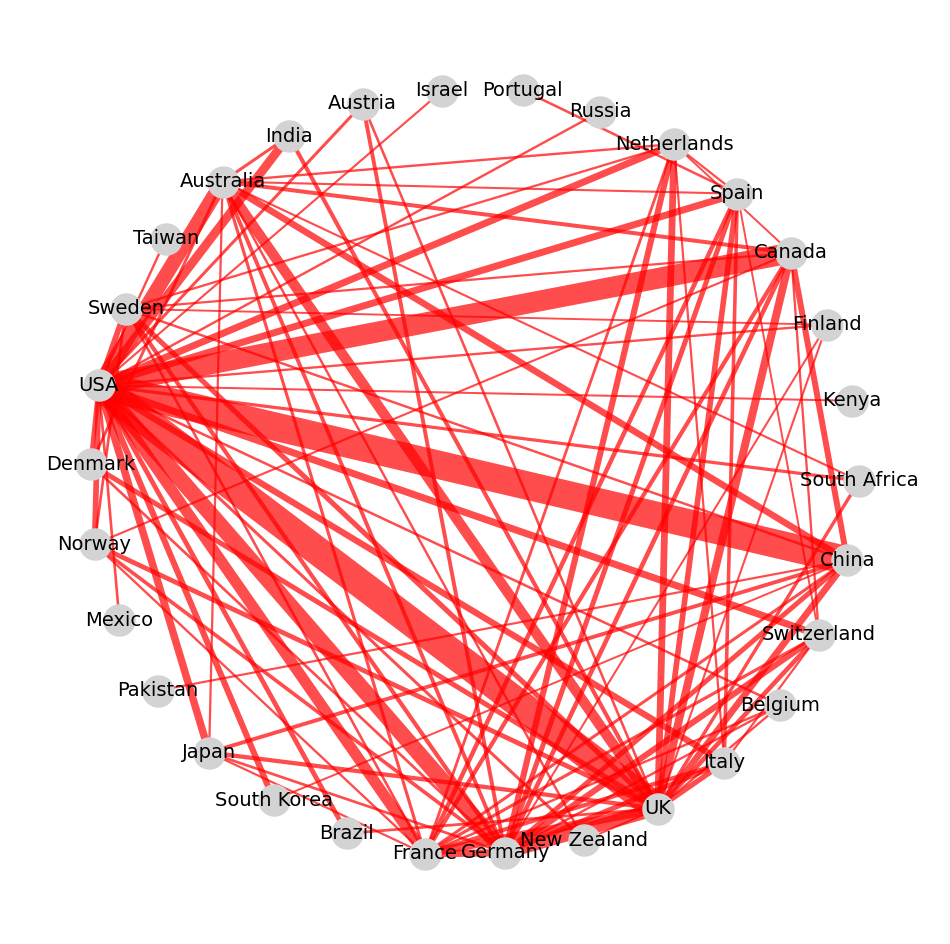

In [ ]:
# the top x collaborations
top_collabs = sorted(collaboration_counter.items(), key=lambda x: x[1], reverse=True)[:100]

G_top = nx.Graph()
for (c1, c2), weight in top_collabs:
    G_top.add_edge(c1, c2, weight=weight)

plt.figure(figsize=(12,12))
pos = nx.spring_layout(G_top, k=1000, scale=5, iterations=1000, seed=123) 
nx.draw_networkx_nodes(G_top, pos, node_size=500, node_color='lightgray', alpha = 1)
nx.draw_networkx_edges(G_top, pos, width=[d['weight']*0.01 for (u,v,d) in G_top.edges(data=True)], edge_color = "red", alpha=0.7)
nx.draw_networkx_labels(G_top, pos, font_size=14, font_color='black')
plt.axis('off')

plt.savefig('/Users/trevor/Desktop/Research/climate-trends/Figures/top-100-colab.pdf')

plt.show()


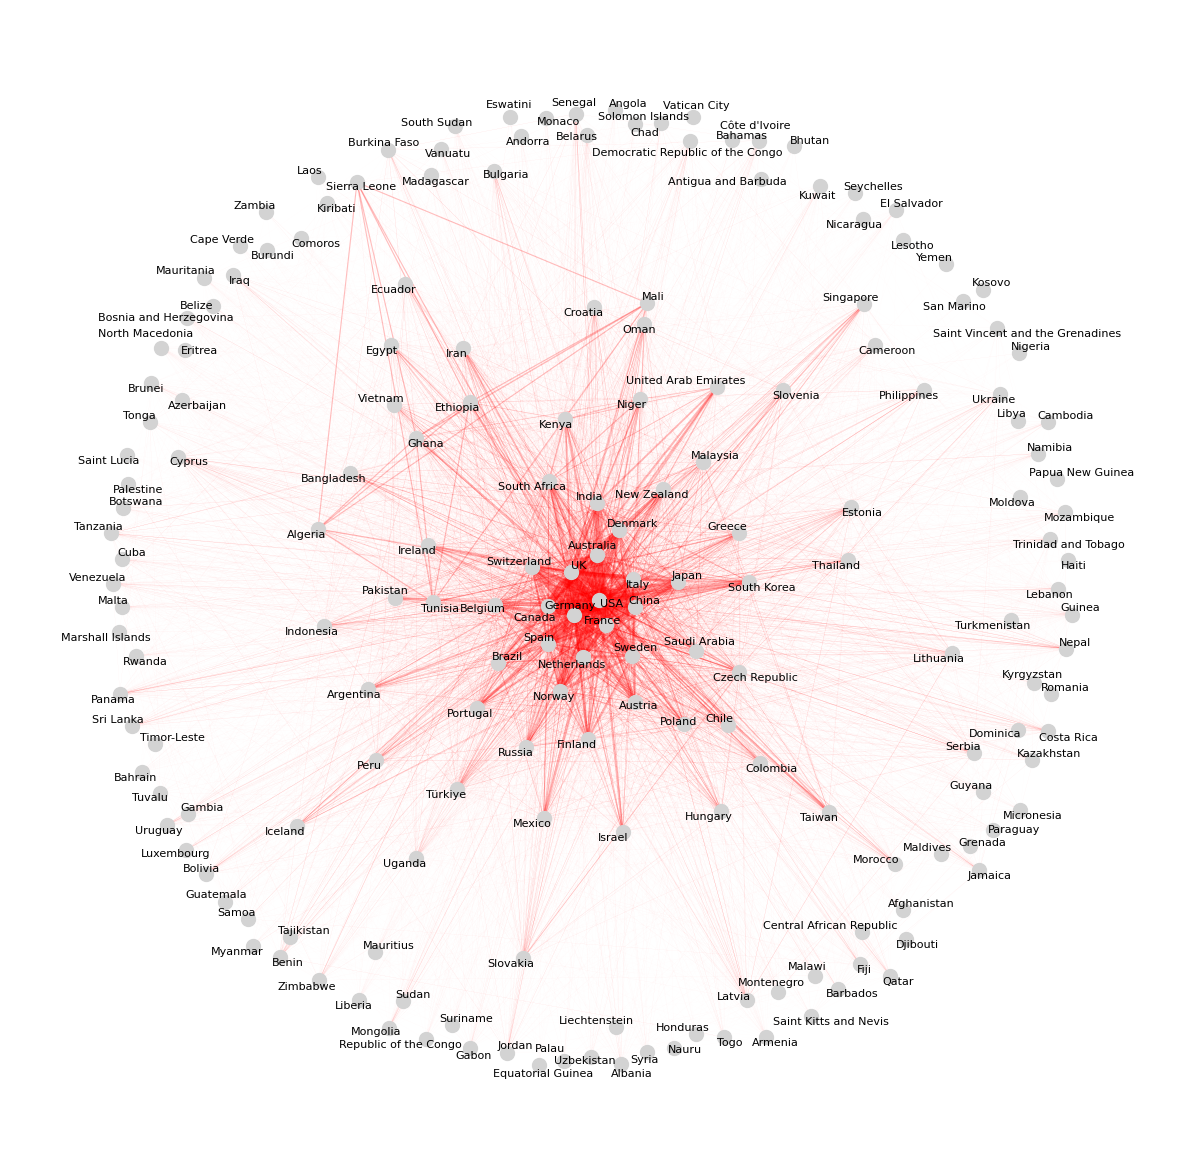

In [718]:
plt.figure(figsize=(15,15))
pos = nx.spring_layout(G, k=7.5, iterations=100, scale = 2)
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightgray')
edges = G.edges(data=True)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[d['weight']*0.01 for (u,v,d) in edges], edge_color = "red", alpha = 0.25)
#nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')
texts = []
for node, (x, y) in pos.items():
    texts.append(plt.text(x, y, str(node), fontsize=8, ha='center', va='center'))
adjust_text(texts) 
plt.axis('off')

plt.savefig('/Users/trevor/Desktop/Research/climate-trends/Figures/full-network.pdf')
plt.savefig('/Users/trevor/Desktop/Research/climate-trends/Figures/full-network.png', dpi = 800)

plt.show()

In [806]:
country_loc = pd.read_excel('/Users/trevor/Desktop/Research/Data/country-loc.xlsx')

In [807]:
country_loc.shape

(197, 6)

In [810]:
affiliation_counts

affiliation_list
USA              27400
China            11074
UK                9473
Germany           6089
Canada            5763
                 ...  
Timor-Leste          1
Liechtenstein        1
North Korea          1
Turkmenistan         1
Saint Lucia          1
Name: count, Length: 192, dtype: int64

In [814]:
afil_2023 = pd.DataFrame(exploded_df[exploded_df['earliest_pub_year'] == 2023].value_counts('affiliation_list')).reset_index()

In [817]:
afil_2023_merged = pd.merge(afil_2023, country_loc[['name', 'population_2023']], left_on = 'affiliation_list', right_on ='name')

In [819]:
afil_2023_merged['per_capita_output'] = afil_2023_merged['count'] / afil_2023_merged['population_2023']

In [836]:
p25 = np.percentile(afil_2023_merged['count'], 25)
p50 = np.percentile(afil_2023_merged['count'], 50)

In [839]:
for _, row in afil_2023_merged.sort_values('per_capita_output', ascending = False).iterrows():
    print(row['name'], row['per_capita_output'])

Iceland 4.26305159891079e-05
Denmark 3.908025714470844e-05
Norway 3.087118859556185e-05
San Marino 2.9724748825872423e-05
Latvia 2.9504794802347927e-05
Andorra 2.4972530216761563e-05
Australia 2.4206562769829894e-05
Sweden 2.0919543999172265e-05
South Korea 1.9659483319920394e-05
Switzerland 1.841606180703173e-05
Austria 1.7859215801834142e-05
Samoa 1.772413273603006e-05
Portugal 1.6784409625468586e-05
New Zealand 1.6258296513073585e-05
Finland 1.6229448334002047e-05
Oman 1.6148535521610616e-05
United Arab Emirates 1.5971636055590118e-05
Canada 1.5677662716282448e-05
UK 1.5073046997406226e-05
Netherlands 1.5041179628067387e-05
Ireland 1.4633369817883758e-05
Fiji 1.3883326658657056e-05
Dominica 1.3691128148959475e-05
Estonia 1.3607859294734892e-05
Malta 1.3082547134548391e-05
Greece 1.1990782182896754e-05
Lithuania 1.0668228397205366e-05
Antigua and Barbuda 1.0604678784279624e-05
Germany 1.0324794876039613e-05
Belgium 9.669574384698455e-06
Montenegro 9.57724446714606e-06
Cyprus 9.522766

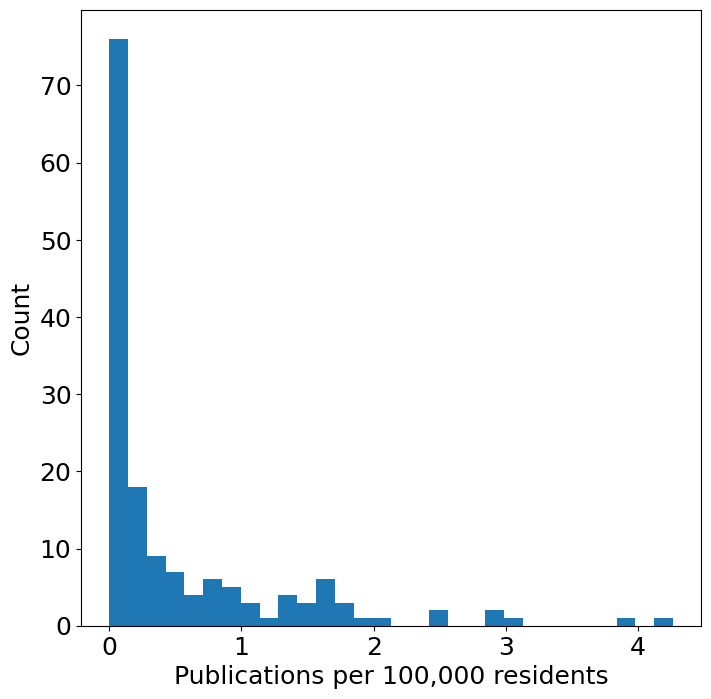

In [849]:
plt.figure(figsize = (8,8))
plt.hist(afil_2023_merged['per_capita_output']*100000, bins = 30)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('Publications per 100,000 residents', fontsize = 18)
plt.ylabel('Count', fontsize = 18)
plt.savefig('/Users/trevor/Desktop/Research/climate-trends/Figures/per_capita_pub.png', dpi = 600)

In [840]:
for _, row in afil_2023_merged.sort_values('count', ascending = False).iterrows():
    print(row['name'], row['count'])

USA 2269
China 1907
UK 1021
Germany 860
Australia 640
India 609
Canada 608
Italy 427
Spain 398
France 312
Netherlands 265
Japan 237
Denmark 231
Sweden 222
South Korea 218
Brazil 208
South Africa 195
Poland 181
Portugal 172
Norway 169
Russia 163
Switzerland 162
Austria 160
United Arab Emirates 152
Saudi Arabia 143
Türkiye 125
Greece 124
Iran 123
Ethiopia 119
Pakistan 119
Belgium 113
Niger 105
Malaysia 104
Mexico 103
Kenya 102
Finland 90
Czech Republic 88
New Zealand 85
Indonesia 85
Oman 75
Ireland 74
Taiwan 71
Egypt 71
Chile 64
Thailand 63
Israel 57
Latvia 54
Bangladesh 54
Ghana 53
Singapore 47
Hungary 46
Vietnam 44
Argentina 44
Colombia 38
Peru 32
Serbia 32
Croatia 32
Philippines 30
Tunisia 30
Lithuania 29
Algeria 28
Iraq 25
Jordan 23
Morocco 23
Slovakia 23
Ukraine 22
Benin 21
Slovenia 20
Estonia 18
Nepal 18
Kazakhstan 18
Ecuador 17
Sri Lanka 17
Bulgaria 16
Iceland 16
Qatar 15
Tanzania 15
Mali 14
Fiji 13
Cameroon 13
Sierra Leone 12
Cyprus 12
Senegal 11
Zimbabwe 10
Uganda 10
Burkina Fas

In [582]:
pos = {row['name']: (row['longitude'], row['latitude']) for _, row in country_loc.iterrows()}


In [583]:
for country in country_loc['name']:
    if country not in countries:
        print(country)

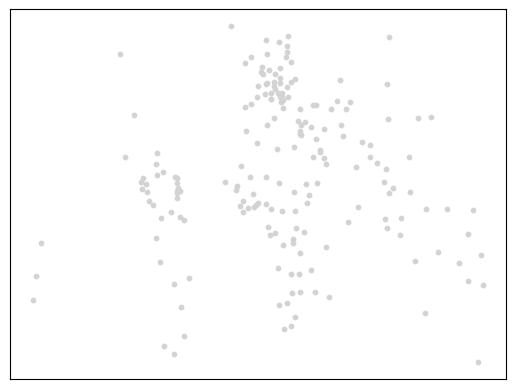

In [584]:
nx.draw_networkx_nodes(G, pos, node_size=10, node_color='lightgray')


In [ ]:
node_sizes = [affiliation_dict.get(country, 1) * 0.05 for country in G.nodes()]

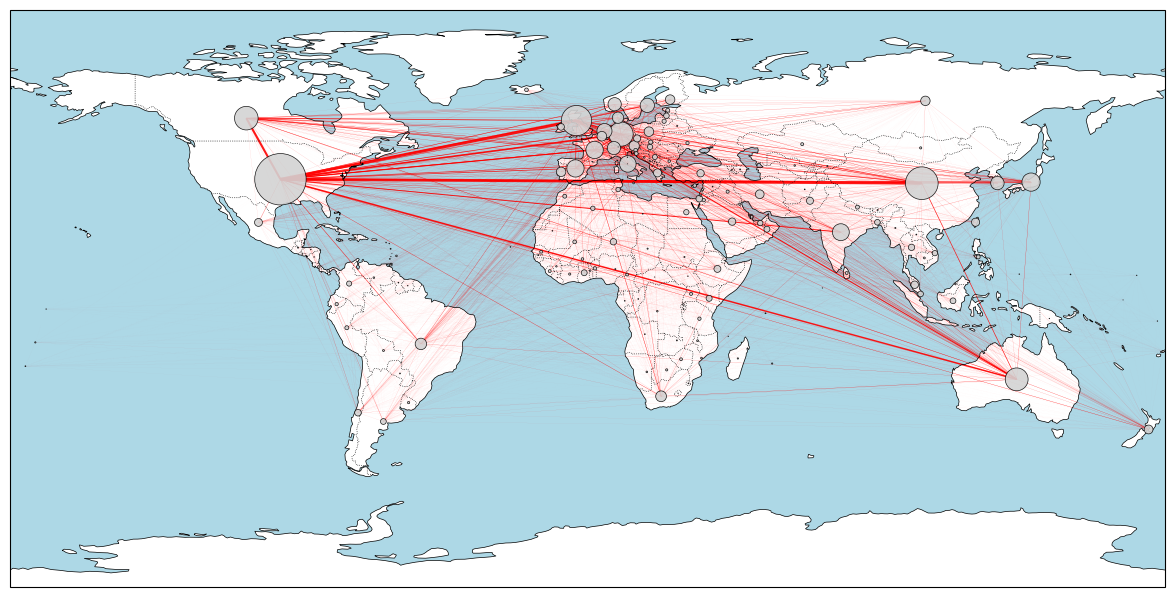

In [693]:

plt.figure(figsize=(15,7.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(linewidth = 0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth = 0.5)
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, 
    node_color='lightgray', edgecolors = "black", linewidths= 0.5, alpha = 0.9)
edges = G.edges(data=True)
nx.draw_networkx_edges(
    G, pos, edgelist=edges,
    width=[d['weight'] * 0.001 for (_, _, d) in edges],
    edge_color="red", alpha=0.9, ax=ax
)

In [429]:
affiliated_df['n_affiliation'] = affiliated_df['affiliation_list'].apply(lambda x: len(x))

In [723]:
affiliated_df[affiliated_df['n_affiliation']>0].shape

(81141, 55)

In [430]:
n_afil = affiliated_df[affiliated_df['n_affiliation']>0].value_counts('n_affiliation')

In [730]:
single_exploded_df = affiliated_df[affiliated_df['n_affiliation'] == 1].explode('affiliation_list')

In [736]:
for index, value in single_exploded_df.value_counts('affiliation_list').items():
    print(index, value)

USA 17240
China 6752
UK 4064
Canada 2947
Australia 2648
Germany 2441
Japan 2122
India 1605
Spain 1313
Italy 1212
South Korea 1020
Netherlands 817
France 811
Sweden 746
Norway 675
Brazil 570
South Africa 564
Poland 529
Switzerland 524
Portugal 409
Russia 402
Iran 388
Austria 383
Denmark 375
Greece 356
Finland 343
Taiwan 335
Türkiye 296
Mexico 287
Belgium 279
New Zealand 269
Malaysia 252
Latvia 232
Ethiopia 199
Oman 197
Israel 195
Czech Republic 192
Thailand 190
Ireland 171
Serbia 143
Chile 142
Niger 141
Indonesia 140
Saudi Arabia 139
Hungary 130
Pakistan 130
Singapore 118
Argentina 117
Lithuania 101
Bangladesh 95
Egypt 91
Ghana 88
Vietnam 83
Slovakia 77
Kenya 67
Colombia 64
Croatia 62
Philippines 56
United Arab Emirates 55
Ukraine 50
Slovenia 48
Algeria 48
Estonia 47
Tanzania 46
Cyprus 43
Morocco 42
Nepal 37
Sri Lanka 33
Zimbabwe 32
Bulgaria 32
Iceland 30
Peru 30
Jordan 29
Benin 29
Iraq 28
Uganda 27
Tunisia 25
Kazakhstan 25
Qatar 24
Ecuador 23
Panama 23
Cameroon 22
Kuwait 20
Botswana 19

In [733]:
colab_exploded_df = affiliated_df[affiliated_df['n_affiliation'] > 1].explode('affiliation_list')

In [737]:
for index, value in colab_exploded_df.value_counts('affiliation_list').items():
    print(index, value)

USA 10160
UK 5409
China 4322
Germany 3648
Canada 2816
Australia 2753
France 2311
Spain 1780
Italy 1614
Netherlands 1522
Sweden 1369
India 1353
Japan 1318
Switzerland 1284
Norway 1150
Denmark 956
South Korea 846
Brazil 787
Austria 703
Belgium 685
South Africa 640
Finland 597
New Zealand 539
Russia 526
Portugal 513
Poland 426
Saudi Arabia 421
Iran 396
Pakistan 386
Mexico 361
Taiwan 358
Malaysia 335
Czech Republic 334
Greece 327
Chile 312
Kenya 306
Ethiopia 299
Ireland 296
Niger 285
Ghana 274
Israel 269
Türkiye 267
United Arab Emirates 237
Bangladesh 236
Argentina 233
Thailand 230
Singapore 218
Vietnam 212
Colombia 209
Indonesia 208
Egypt 204
Tunisia 181
Oman 171
Hungary 158
Algeria 153
Mali 142
Peru 137
Nepal 127
Estonia 114
Morocco 114
Serbia 113
Iceland 111
Philippines 105
Slovakia 100
Cyprus 92
Latvia 92
Ecuador 89
Croatia 89
Benin 89
Sierra Leone 89
Slovenia 88
Lithuania 85
Jordan 84
Senegal 80
Uganda 72
Tanzania 72
Iraq 72
Kazakhstan 67
Burkina Faso 65
Ukraine 62
Cameroon 59
Panama 

In [729]:
57441/ 81141 

0.707915850186712

In [728]:
1 - 57441/ 81141 

0.292084149813288

In [726]:
n_afil

n_affiliation
1     57441
2     16819
3      4080
4      1232
5       641
6       256
7       231
9       120
8       114
10       58
11       35
12       26
13       23
14       18
16        8
15        7
17        5
18        5
19        4
20        4
24        3
25        3
30        2
21        1
22        1
28        1
29        1
34        1
39        1
Name: count, dtype: int64

Text(0, 0.5, 'Count')

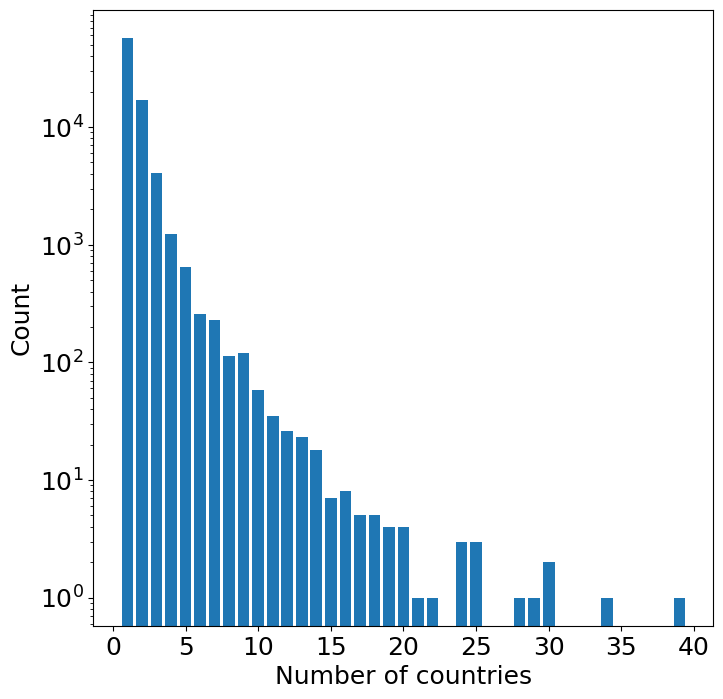

In [469]:
plt.figure(figsize=(8,8))
plt.bar(n_afil.index, n_afil.values)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.yscale('log')
plt.xlabel('Number of countries', fontsize = 18)
plt.ylabel('Count', fontsize = 18)

In [434]:
# Weight (collaboration count) -- note this doesn't include single country papers 
strength = {node: sum(data['weight'] for _, _, data in G.edges(node, data=True)) for node in G.nodes()}
most_weighted = sorted(strength.items(), key=lambda x: x[1], reverse=True)
most_weighted

[('USA', 18451),
 ('UK', 12979),
 ('Germany', 9186),
 ('China', 7076),
 ('France', 6459),
 ('Australia', 6432),
 ('Canada', 6015),
 ('Spain', 4745),
 ('Netherlands', 4449),
 ('Italy', 4373),
 ('Sweden', 3786),
 ('Switzerland', 3679),
 ('Norway', 3311),
 ('Denmark', 3203),
 ('India', 3193),
 ('Japan', 3084),
 ('Austria', 2248),
 ('Belgium', 2213),
 ('Brazil', 2206),
 ('South Africa', 2158),
 ('Finland', 1944),
 ('South Korea', 1518),
 ('Portugal', 1512),
 ('New Zealand', 1439),
 ('Russia', 1430),
 ('Poland', 1338),
 ('Czech Republic', 1267),
 ('Kenya', 1179),
 ('Niger', 1069),
 ('Greece', 1052),
 ('Ghana', 1022),
 ('Ireland', 1007),
 ('Ethiopia', 984),
 ('Mexico', 953),
 ('United Arab Emirates', 938),
 ('Chile', 891),
 ('Saudi Arabia', 847),
 ('Türkiye', 833),
 ('Argentina', 812),
 ('Malaysia', 806),
 ('Tunisia', 788),
 ('Iran', 761),
 ('Pakistan', 759),
 ('Israel', 746),
 ('Algeria', 722),
 ('Mali', 721),
 ('Colombia', 676),
 ('Hungary', 657),
 ('Taiwan', 656),
 ('Estonia', 570),
 ('Pe

In [435]:
# Betweenness centrality
# How often a node lies on the shortest path between all nodes in a network

betweenness_centrality = nx.betweenness_centrality(G, weight='weight')
most_influential = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
most_influential

[('France', 0.028451932082935182),
 ('China', 0.026832541057246303),
 ('Guinea', 0.02551779583806918),
 ('Japan', 0.025081639169430108),
 ('India', 0.02403649348279522),
 ('USA', 0.023697492460926874),
 ('Norway', 0.022423048363781024),
 ('Germany', 0.021831024264783224),
 ('Ethiopia', 0.020844843560769318),
 ('Suriname', 0.0195696570005025),
 ('Brazil', 0.019114811660257004),
 ('Guyana', 0.018664001983254436),
 ('Australia', 0.017397920665739818),
 ('New Zealand', 0.017115087506617863),
 ('Switzerland', 0.01694773351446648),
 ('Chile', 0.016907078283330386),
 ('Morocco', 0.016802403263199112),
 ('Cuba', 0.016535280985000726),
 ('Austria', 0.015973244970186738),
 ('Colombia', 0.015052830002913927),
 ('UK', 0.013036484427763322),
 ('Italy', 0.01265228188579571),
 ('Bangladesh', 0.012236480017231585),
 ('Trinidad and Tobago', 0.011850692660392684),
 ('Canada', 0.011769330326161676),
 ('Mauritania', 0.011702866670461963),
 ('Bosnia and Herzegovina', 0.011525881544117019),
 ('Angola', 0.01

In [436]:
# Closeness centrality
# How close a node is to all other nodes in a graph

closeness_centrality = nx.closeness_centrality(G)
most_accessible = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)
most_accessible


[('USA', 0.926829268292683),
 ('UK', 0.8837209302325582),
 ('France', 0.8370044052863436),
 ('Germany', 0.8333333333333334),
 ('Australia', 0.8016877637130801),
 ('Spain', 0.7949790794979079),
 ('Canada', 0.7916666666666666),
 ('Netherlands', 0.7818930041152263),
 ('China', 0.7786885245901639),
 ('Italy', 0.753968253968254),
 ('India', 0.7480314960629921),
 ('Switzerland', 0.7421875),
 ('Belgium', 0.7392996108949417),
 ('Brazil', 0.7392996108949417),
 ('South Africa', 0.7279693486590039),
 ('Norway', 0.7196969696969697),
 ('Japan', 0.7089552238805971),
 ('Sweden', 0.7011070110701108),
 ('Austria', 0.7011070110701108),
 ('Niger', 0.7011070110701108),
 ('New Zealand', 0.6959706959706959),
 ('Portugal', 0.6934306569343066),
 ('Denmark', 0.6859205776173285),
 ('Kenya', 0.6834532374100719),
 ('Malaysia', 0.6834532374100719),
 ('Colombia', 0.6785714285714286),
 ('Finland', 0.6737588652482269),
 ('Chile', 0.6737588652482269),
 ('Türkiye', 0.6737588652482269),
 ('Peru', 0.6737588652482269),
 (

In [437]:
# Eigenvector centrality
# Measure of influence based on influence of neighbors

eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight')
most_influential_eigen = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True) 
most_influential_eigen

[('USA', 0.5387771423120676),
 ('UK', 0.40945114102010377),
 ('China', 0.3040007579550782),
 ('Germany', 0.2923401614492564),
 ('Canada', 0.256912939449318),
 ('Australia', 0.2331699134973235),
 ('France', 0.21247963025412628),
 ('Netherlands', 0.14965455168951283),
 ('Spain', 0.14433480247031102),
 ('Italy', 0.13521471190582243),
 ('Switzerland', 0.13356569670212573),
 ('Sweden', 0.12613607962020953),
 ('Japan', 0.12064410381230664),
 ('India', 0.11474846596477542),
 ('Norway', 0.11431937835141645),
 ('Denmark', 0.1054168617906451),
 ('Brazil', 0.07280923524701507),
 ('Austria', 0.0716186896494785),
 ('South Korea', 0.0667193151956336),
 ('Belgium', 0.066049302844639),
 ('South Africa', 0.06529634922175043),
 ('Finland', 0.05829218390266559),
 ('New Zealand', 0.0538638434532755),
 ('Russia', 0.046028051238567555),
 ('Portugal', 0.04030685474254639),
 ('Mexico', 0.03398863094740643),
 ('Ireland', 0.033877059834372565),
 ('Poland', 0.033825042671176905),
 ('Kenya', 0.032937829912711006)

In [438]:
# Community detection
cliques = list(nx.find_cliques(G))

# clustering coefficient
# Likelihood that neighbors are connected
clustering = nx.clustering(G)
most_clustered = sorted(clustering.items(), key=lambda x: x[1], reverse=True) 

In [439]:
sorted(list(nx.find_cliques(G)), key = len, reverse = True)

[['USA',
  'UK',
  'Germany',
  'France',
  'Spain',
  'Australia',
  'Canada',
  'China',
  'Switzerland',
  'Italy',
  'Latvia',
  'Russia',
  'Poland',
  'Czech Republic',
  'Netherlands',
  'Denmark',
  'Norway',
  'Türkiye',
  'Belgium',
  'Austria',
  'Portugal',
  'Morocco',
  'Sweden',
  'Finland',
  'Estonia',
  'Greece',
  'Slovakia',
  'Cyprus',
  'Slovenia',
  'Tunisia',
  'Hungary',
  'Ireland',
  'Israel',
  'Croatia',
  'Belarus',
  'Oman',
  'Lithuania',
  'Bulgaria',
  'Ukraine',
  'Algeria',
  'South Africa'],
 ['USA',
  'UK',
  'Germany',
  'France',
  'Spain',
  'Australia',
  'Canada',
  'China',
  'Switzerland',
  'Italy',
  'Latvia',
  'Russia',
  'Poland',
  'Czech Republic',
  'Netherlands',
  'Denmark',
  'Norway',
  'Türkiye',
  'Belgium',
  'Austria',
  'Portugal',
  'Morocco',
  'Sweden',
  'Finland',
  'Estonia',
  'Greece',
  'Slovakia',
  'Cyprus',
  'Slovenia',
  'Tunisia',
  'Hungary',
  'Ireland',
  'Israel',
  'Croatia',
  'Belarus',
  'Oman',
  'Lit

In [441]:
# probably a better way to do look at cliques
for index, value in affiliated_df['affiliation_list'].value_counts().items():
    print(index, value)

['USA'] 17240
['China'] 6752
['UK'] 4064
['Canada'] 2947
['Australia'] 2648
['Germany'] 2441
['Japan'] 2122
['India'] 1605
['Spain'] 1313
['Italy'] 1212
[] 1194
['China', 'USA'] 1036
['South Korea'] 1020
['Netherlands'] 817
['France'] 811
['Sweden'] 746
['Norway'] 675
['Brazil'] 570
['South Africa'] 564
['Poland'] 529
['Switzerland'] 524
['USA', 'UK'] 432
['Portugal'] 409
['Russia'] 402
['Iran'] 388
['Austria'] 383
['USA', 'Canada'] 378
['Denmark'] 375
['Canada', 'USA'] 371
['Greece'] 356
['Finland'] 343
['Taiwan'] 335
['UK', 'USA'] 335
['USA', 'China'] 323
['Türkiye'] 296
['Mexico'] 287
['Belgium'] 279
['New Zealand'] 269
['Malaysia'] 252
['Latvia'] 232
['Australia', 'USA'] 209
['China', 'Australia'] 202
['Ethiopia'] 199
['Oman'] 197
['Israel'] 195
['Czech Republic'] 192
['Thailand'] 190
['China', 'Canada'] 188
['USA', 'India'] 175
['USA', 'Australia'] 173
['Ireland'] 171
['China', 'UK'] 161
['India', 'USA'] 156
['USA', 'Germany'] 153
['South Korea', 'USA'] 149
['Serbia'] 143
['Chile'

In [751]:
# This looks at individual "team" representations, rather than the total collaborations across teams
for index, value in affiliated_df['affiliation_list'].apply(lambda x : set(x)).value_counts().items():
    if len(index) > 1:
        print(index, value)

{'China', 'USA'} 1359
{'USA', 'UK'} 767
{'Canada', 'USA'} 749
{'Australia', 'USA'} 382
{'India', 'USA'} 331
{'Germany', 'USA'} 281
{'USA', 'South Korea'} 274
{'Australia', 'China'} 252
{'Canada', 'China'} 236
{'France', 'USA'} 212
{'Japan', 'USA'} 196
{'China', 'UK'} 187
{'Australia', 'UK'} 178
{'Germany', 'UK'} 172
{'Switzerland', 'USA'} 145
{'Brazil', 'USA'} 140
{'Italy', 'USA'} 133
{'Canada', 'UK'} 130
{'USA', 'Spain'} 125
{'Japan', 'China'} 121
{'Switzerland', 'Germany'} 115
{'Germany', 'China'} 112
{'Norway', 'USA'} 105
{'Taiwan', 'USA'} 104
{'Sweden', 'USA'} 103
{'Netherlands', 'USA'} 103
{'Japan', 'UK'} 101
{'Netherlands', 'UK'} 99
{'Spain', 'UK'} 87
{'Pakistan', 'China'} 86
{'Mexico', 'USA'} 86
{'Germany', 'Netherlands'} 85
{'Canada', 'Australia'} 79
{'France', 'UK'} 77
{'Italy', 'UK'} 77
{'Germany', 'Austria'} 75
{'Ghana', 'Mali', 'Sierra Leone', 'Ethiopia', 'Tunisia', 'UK', 'Algeria'} 74
{'France', 'Germany'} 74
{'Italy', 'Spain'} 73
{'Australia', 'New Zealand'} 72
{'Sweden',

In [755]:
# This looks at individual "team" representations, rather than the total collaborations across teams
for index, value in affiliated_df['affiliation_list'].apply(lambda x : set(x)).value_counts().items():
    if len(index) > 2:
        print(index, value)

{'Ghana', 'Mali', 'Sierra Leone', 'Ethiopia', 'Tunisia', 'UK', 'Algeria'} 74
{'United Arab Emirates', 'Australia', 'India', 'UK', 'Denmark'} 67
{'Canada', 'USA', 'UK'} 63
{'Germany', 'USA', 'UK'} 62
{'Australia', 'USA', 'UK'} 49
{'Canada', 'China', 'USA'} 44
{'United Arab Emirates', 'Kenya', 'USA', 'Australia', 'Niger', 'UK', 'India', 'Denmark', 'South Africa'} 42
{'Australia', 'China', 'USA'} 36
{'China', 'USA', 'UK'} 36
{'Japan', 'USA', 'China'} 32
{'France', 'USA', 'UK'} 30
{'Canada', 'Australia', 'USA'} 25
{'Netherlands', 'USA', 'UK'} 22
{'China', 'USA', 'South Korea'} 22
{'Canada', 'France', 'USA'} 21
{'India', 'China', 'USA'} 20
{'Canada', 'Germany', 'USA'} 20
{'Germany', 'China', 'USA'} 17
{'Sweden', 'USA', 'UK'} 16
{'Switzerland', 'Germany', 'USA'} 16
{'Switzerland', 'USA', 'UK'} 15
{'Italy', 'USA', 'UK'} 15
{'USA', 'Germany', 'Spain'} 15
{'Japan', 'USA', 'UK'} 14
{'Switzerland', 'China', 'USA'} 14
{'Japan', 'USA', 'South Korea'} 14
{'France', 'China', 'USA'} 13
{'France', 'Ger

In [360]:
most_clustered

[('Romania', 1.0),
 ('Haiti', 1.0),
 ('Saint Vincent and the Grenadines', 1.0),
 ('Paraguay', 1.0),
 ('Lesotho', 1.0),
 ('Cape Verde', 1.0),
 ('Kiribati', 1.0),
 ('Tuvalu', 1.0),
 ('Nauru', 1.0),
 ('Nigeria', 1.0),
 ('Antigua and Barbuda', 1.0),
 ('Saint Lucia', 1.0),
 ('Bhutan', 1.0),
 ('San Marino', 1.0),
 ('Eritrea', 1.0),
 ('Equatorial Guinea', 1.0),
 ('Moldova', 1.0),
 ('Central African Republic', 1.0),
 ('Eswatini', 1.0),
 ('Andorra', 0.9969230769230769),
 ('Comoros', 0.993103448275862),
 ('Luxembourg', 0.9762845849802372),
 ('North Macedonia', 0.9750445632798574),
 ('Montenegro', 0.9743589743589743),
 ('Albania', 0.973170731707317),
 ('Monaco', 0.9714285714285714),
 ('Afghanistan', 0.9705882352941176),
 ('South Sudan', 0.968705547652916),
 ('Republic of the Congo', 0.9637681159420289),
 ('Palau', 0.9583333333333334),
 ('Bosnia and Herzegovina', 0.9581881533101045),
 ('Mongolia', 0.9572192513368984),
 ('Libya', 0.9555555555555556),
 ('Burundi', 0.9487179487179487),
 ('Palestine',

In [374]:
gini = inequality.gini(affiliation_counts.values)
gini


# has science become more or less distributed?

0.8697063808499453

In [676]:
def calc_int_colab_prop(series):
    return (1 - (sum(series == 1) / len(series)))*100

proportion_int = pd.DataFrame(affiliated_df[affiliated_df['n_affiliation'] > 0].groupby('earliest_pub_year')['n_affiliation'].apply(calc_int_colab_prop)).reset_index()

In [636]:
proportion_int

,earliest_pub_year,n_affiliation
0,2000,10.526316
1,2001,15.444015
2,2002,22.048998
3,2003,18.164794
4,2004,22.344322
5,2005,19.428571
6,2006,22.532588
7,2007,24.570447
8,2008,23.648161
9,2009,23.276407


In [757]:
model  =smf.ols("n_affiliation ~ earliest_pub_year", proportion_int).fit()

In [758]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          n_affiliation   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     81.82
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           7.25e-09
Time:                        15:01:19   Log-Likelihood:                -57.051
No. Observations:                  24   AIC:                             118.1
Df Residuals:                      22   BIC:                             120.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1435.4612    161.511     -8.888      0.000   -1770.415   -1100.507
earliest_pub_year     0.7263      0.080      9.045      0.000       0.560       0.893
==============================================================================
Omnibus:                        4.426   Durbin-Watson:                   0.969
Prob(Omnibus):                  0.109   Jarque-Bera (JB):                3.026
Skew:                          -0.861   Prob(JB):                        0.220
Kurtosis:                       3.243   Cond. No.                     5.85e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.85e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [759]:
model.pvalues

Intercept            9.857979e-09
earliest_pub_year    7.249920e-09
dtype: float64

In [652]:
x_vals = np.linspace(proportion_int["earliest_pub_year"].min(), proportion_int["earliest_pub_year"].max(), 100)  
y_vals = model.params[0] + model.params[1] * x_vals 


/var/folders/1g/6pgh6bw14hgcbgppl7q0jgfr0000gn/T/ipykernel_709/1284970201.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = model.params[0] + model.params[1] * x_vals


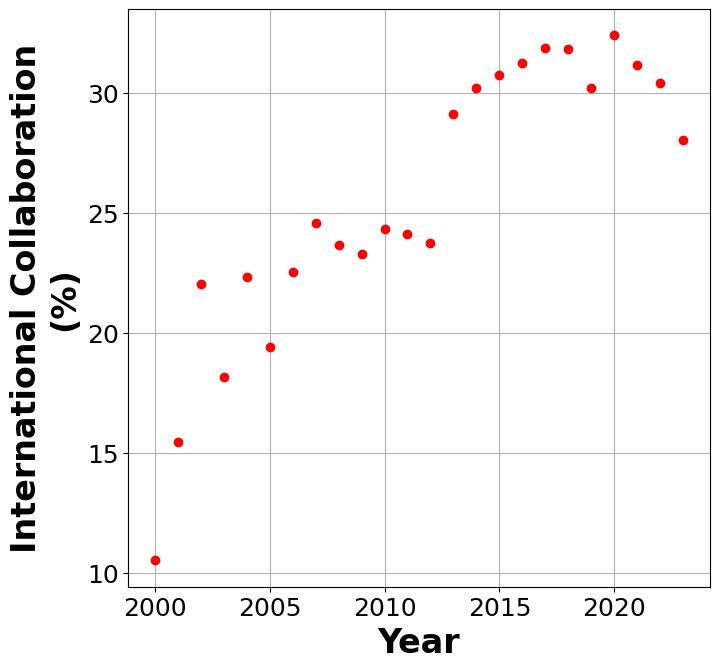

In [694]:
plt.figure(figsize = (7.5,7.5))
plt.grid(True)
plt.scatter(proportion_int['earliest_pub_year'], proportion_int['n_affiliation'], color = "red", zorder = 2)
#plt.plot(x_vals, y_vals, color="red", linestyle="--", label="OLS Fit")
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.xlabel('Year', fontsize = 24, fontweight = "bold")
plt.ylabel('International Collaboration\n(%)', fontsize = 24, fontweight = "bold")
plt.show()

In [609]:
affiliated_df['earliest_pub_year']

0        2000
1        2000
2        2000
3        2000
4        2000
         ... 
82330    2023
82331    2023
82332    2023
82333    2023
82334    2023
Name: earliest_pub_year, Length: 82335, dtype: int64

In [ ]:
observed = exploded_df.value_counts('affiliation_list').values

In [795]:
np.sum(observed)

119369

In [796]:
observed.shape[0]

192

In [797]:
expected = [np.sum(observed) / observed.shape[0] for i in range(observed.shape[0])]

In [800]:
chi2, p = stats.chisquare(observed, expected)

In [801]:
chi2

1728130.3739413086

In [802]:
p

0.0

In [659]:
def calc_gini(series):
    return inequality.gini(series.value_counts().values)


gini_years = pd.DataFrame(exploded_df[exploded_df['n_affiliation'] > 0].groupby('earliest_pub_year')['affiliation_list'].apply(calc_gini)).reset_index()

In [764]:
gini_years

,earliest_pub_year,affiliation_list
0,2000,0.716327
1,2001,0.711197
2,2002,0.780218
3,2003,0.773079
4,2004,0.762973
5,2005,0.830299
6,2006,0.838477
7,2007,0.817025
8,2008,0.824905
9,2009,0.832145


In [789]:
max(gini_years['affiliation_list'])

0.8577676927124487

In [765]:
gini_years['sq_year'] = gini_years['earliest_pub_year']**2

In [770]:
gini_years

,earliest_pub_year,affiliation_list,sq_year
0,2000,0.716327,4000000
1,2001,0.711197,4004001
2,2002,0.780218,4008004
3,2003,0.773079,4012009
4,2004,0.762973,4016016
5,2005,0.830299,4020025
6,2006,0.838477,4024036
7,2007,0.817025,4028049
8,2008,0.824905,4032064
9,2009,0.832145,4036081


In [773]:
model_poly1  =smf.ols("affiliation_list ~ earliest_pub_year", gini_years).fit()

In [774]:
model_poly1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       affiliation_list   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     9.169
Date:                Tue, 11 Feb 2025   Prob (F-statistic):            0.00618
Time:                        15:25:38   Log-Likelihood:                 48.939
No. Observations:                  24   AIC:                            -93.88
Df Residuals:                      22   BIC:                            -91.52
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -5.0954      1.951     -2.612      0.016      -9.141      -1.049
earliest_pub_year     0.0029      0.001      3.028      0.006       0.001       0.005
==============================================================================
Omnibus:                        2.361   Durbin-Watson:                   0.479
Prob(Omnibus):                  0.307   Jarque-Bera (JB):                2.032
Skew:                          -0.658   Prob(JB):                        0.362
Kurtosis:                       2.452   Cond. No.                     5.85e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.85e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [771]:
model_poly2  =smf.ols("affiliation_list ~ earliest_pub_year + sq_year", gini_years).fit()

In [772]:
model_poly2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       affiliation_list   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     57.21
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           3.17e-09
Time:                        15:24:26   Log-Likelihood:                 67.125
No. Observations:                  24   AIC:                            -128.2
Df Residuals:                      21   BIC:                            -124.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -2638.0562    304.881     -8.653      0.000   -3272.092   -2004.021
earliest_pub_year     2.6209      0.303      8.646      0.000       1.990       3.251
sq_year              -0.0007   7.54e-05     -8.636      0.000      -0.001      -0.000
==============================================================================
Omnibus:                        2.181   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.336   Jarque-Bera (JB):                1.150
Skew:                           0.524   Prob(JB):                        0.563
Kurtosis:                       3.222   Cond. No.                     3.83e+11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.83e+11. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [785]:
def calc_F_Test(model1, model2):
    """
    Model 1 should be the simpler model
    """
    if model1.ssr < model2.ssr:
        return("Please ensure that the simpler model is listed first")
    F = ((model1.ssr - model2.ssr) / (model1.df_resid - model2.df_resid))  / (model2.ssr / model2.df_resid)
    p = 1 - stats.f.cdf(F, model1.df_resid - model2.df_resid, model2.df_resid)
    return F, p

In [788]:
calc_F_Test(model_poly1, model_poly2)
# poly 2 signifcantly better

(74.58151066381413, 2.3644694202573646e-08)

In [779]:
model_poly2.ssr
model_poly2.df_resid

0.005228891837434383

In [763]:
poly_coeffs = np.polyfit(gini_years['earliest_pub_year'], gini_years['affiliation_list'], 2)
poly_coeffs

array([-6.50742939e-04,  2.62087577e+00, -2.63805621e+03])

Text(0, 0.5, 'Publication Inequality\n(Gini Index)')

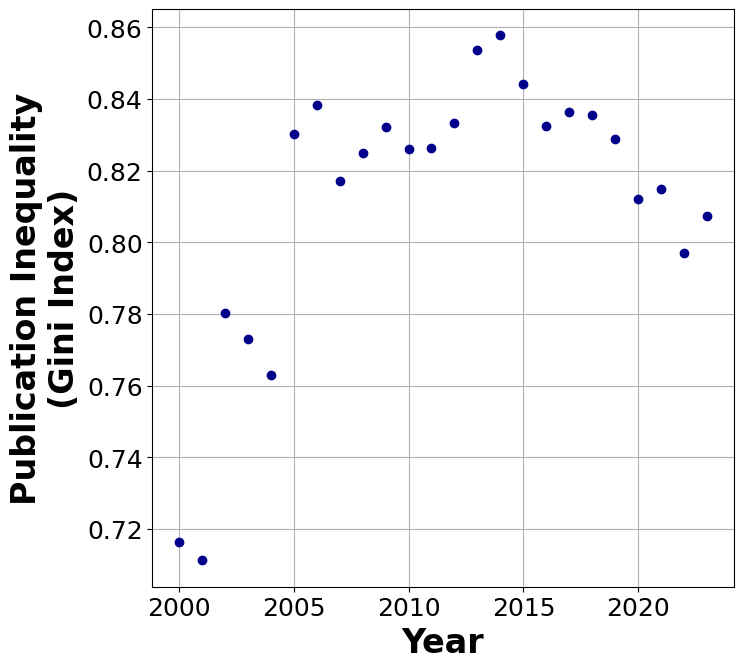

In [695]:
plt.figure(figsize=(7.5,7.5))
plt.scatter(gini_years['earliest_pub_year'], gini_years['affiliation_list'], color = "darkblue", zorder = 2)
plt.grid(True)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.xlabel('Year', fontsize = 24, fontweight = "bold")
plt.ylabel('Publication Inequality\n(Gini Index)', fontsize = 24, fontweight = "bold")

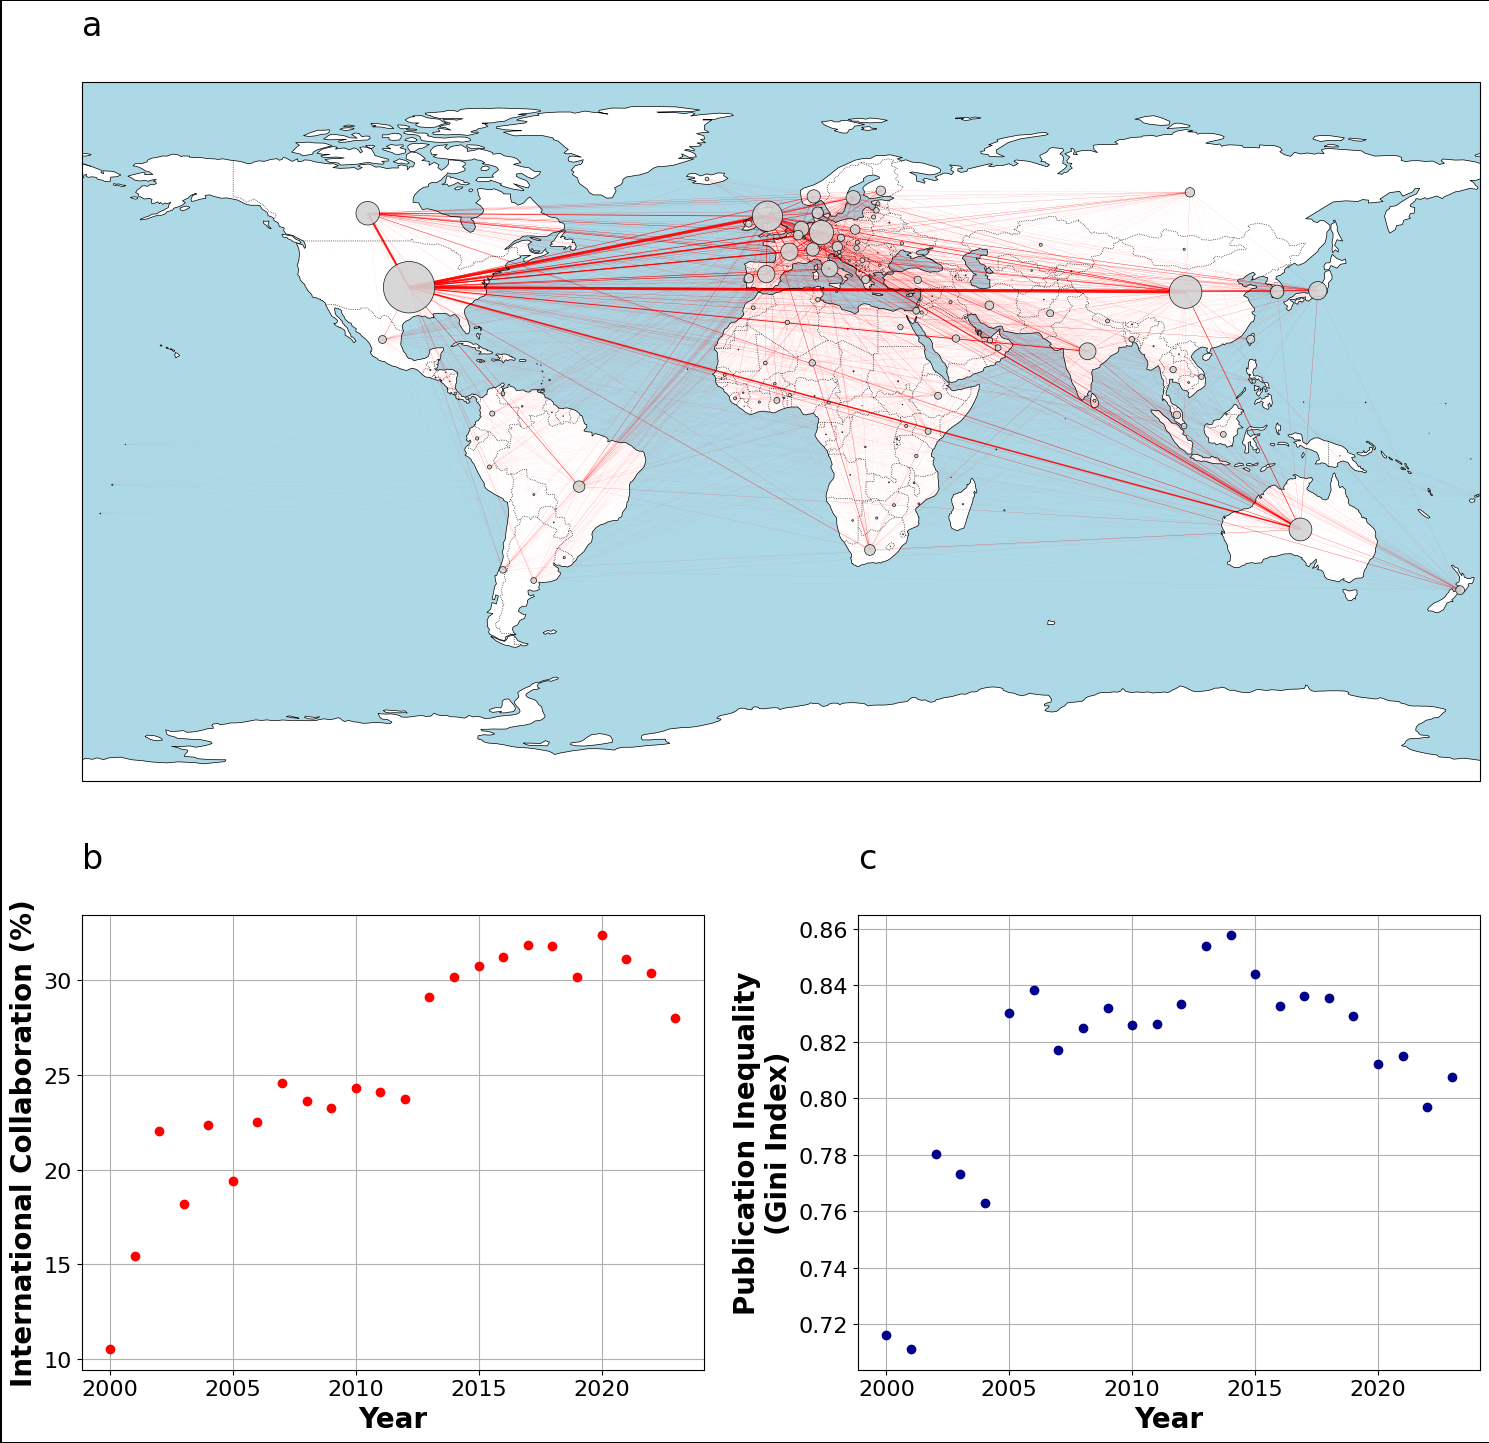

In [716]:
# Create figure with custom layout
fig = plt.figure(figsize=(15, 15))  # Overall figure size
# Add black border to the whole figure
fig.patch.set_linewidth(2)  # Set thickness of the border
fig.patch.set_edgecolor("black")  # Set border color to black

gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])  # First row is taller

### PLOT 1: Global Map with Network (Wide Plot on Top)
ax1 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())  # Span both columns
ax1.set_global()
ax1.coastlines(linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax1.add_feature(cfeature.LAND, facecolor='white')
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.set_title("a\n", fontsize=24, loc="left")

nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, 
    node_color='lightgray', edgecolors="black", linewidths=0.5, alpha=0.9, ax=ax1)
edges = G.edges(data=True)
nx.draw_networkx_edges(
    G, pos, edgelist=edges,
    width=[d['weight'] * 0.001 for (_, _, d) in edges],
    edge_color="red", alpha=0.9, ax=ax1
)

### PLOT 2: International Collaboration Scatter (Bottom Left)
ax2 = fig.add_subplot(gs[1, 0])
ax2.grid(True)
ax2.scatter(proportion_int['earliest_pub_year'], proportion_int['n_affiliation'], 
            color="red", zorder=2)
ax2.set_xlabel('Year', fontsize=20, fontweight="bold")
ax2.set_ylabel('International Collaboration (%)', fontsize=20, fontweight="bold")
ax2.tick_params(axis='both', labelsize=16)
ax2.set_title("b\n", fontsize=24, loc="left")

### PLOT 3: Publication Inequality Scatter (Bottom Right)
ax3 = fig.add_subplot(gs[1, 1])
ax3.grid(True)
ax3.scatter(gini_years['earliest_pub_year'], gini_years['affiliation_list'], 
            color="darkblue", zorder=2)
ax3.set_xlabel('Year', fontsize=20, fontweight="bold")
ax3.set_ylabel('Publication Inequality\n(Gini Index)', fontsize=20, fontweight="bold")
ax3.tick_params(axis='both', labelsize=16)
ax3.set_title("c\n", fontsize=24, loc="left")



# Adjust layout
plt.tight_layout()
plt.savefig('/Users/trevor/Desktop/Research/climate-trends/Figures/map-intcolab-gini.pdf')
plt.show()


In [746]:
communities_generator = nx.community.louvain_communities(G, weight = 'weight')

In [748]:
communities_generator

[{'Albania',
  'Austria',
  'Belarus',
  'Belgium',
  'Bosnia and Herzegovina',
  'Bulgaria',
  'Burundi',
  'Cape Verde',
  'Croatia',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Equatorial Guinea',
  'Estonia',
  'Finland',
  'France',
  'Germany',
  'Greece',
  'Hungary',
  'Iceland',
  'Ireland',
  'Israel',
  'Italy',
  'Kosovo',
  'Latvia',
  'Liechtenstein',
  'Lithuania',
  'Luxembourg',
  'Moldova',
  'Monaco',
  'Montenegro',
  'Morocco',
  'Netherlands',
  'North Macedonia',
  'Norway',
  'Oman',
  'Poland',
  'Portugal',
  'Russia',
  'San Marino',
  'Serbia',
  'Slovakia',
  'Slovenia',
  'South Sudan',
  'Spain',
  'Sweden',
  'Switzerland',
  'Türkiye',
  'Ukraine',
  'Uzbekistan'},
 {'Afghanistan',
  'Australia',
  'Bahrain',
  'Bangladesh',
  'Bhutan',
  'Cambodia',
  'Canada',
  'China',
  'Egypt',
  'Eritrea',
  'India',
  'Indonesia',
  'Iran',
  'Iraq',
  'Japan',
  'Jordan',
  'Kazakhstan',
  'Kuwait',
  'Laos',
  'Libya',
  'Malaysia',
  'Maldiv

In [753]:
len(G)

191